In [1]:
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import random

# 1. KLUE BERT-base 불러오기
tokenizer = BertTokenizer.from_pretrained("klue/bert-base")
bert_model = BertModel.from_pretrained("klue/bert-base")
# BERT 전체 Freeze
for param in bert_model.parameters():
    param.requires_grad = False

# 2. NSMC 데이터셋 불러오기
dataset = load_dataset("nsmc")

# 3. Tokenization 함수
def tokenize_function(example):
    return tokenizer(
        example["document"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["document"])
tokenized_datasets.set_format("torch")

# 4. Custom Dataset
class NSMCDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        return item

train_dataset = NSMCDataset(tokenized_datasets["train"])
test_dataset = NSMCDataset(tokenized_datasets["test"])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 5. Diffusion Noise Module (Forward Process)
class DiffusionNoise(nn.Module):
    def __init__(self, steps=10, noise_scale=0.2):
        super().__init__()
        self.steps = steps
        self.noise_scale = noise_scale

    def forward(self, x):
        for t in range(1, self.steps + 1):
            noise = torch.randn_like(x) * (self.noise_scale * t / self.steps)
            x = x + noise
        return x

# 6. Denoising Head
class DenoisingHead(nn.Module):
    def __init__(self, hidden_size=768):
        super().__init__()
        self.fc = nn.Linear(hidden_size, hidden_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.fc(x))

# 모든 준비 완료 확인
print("BERT 모델, 데이터셋, Noise 모듈, Denoising Head 준비 완료")


tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/150000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/150000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

BERT 모델, 데이터셋, Noise 모듈, Denoising Head 준비 완료


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertTokenizer, BertModel
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm import tqdm

# 1. KLUE BERT-base 불러오기
tokenizer = BertTokenizer.from_pretrained("klue/bert-base")
bert_model = BertModel.from_pretrained("klue/bert-base")
for param in bert_model.parameters():
    param.requires_grad = False  # Freeze 전체 BERT

# 2. NSMC 데이터셋 불러오기
dataset = load_dataset("nsmc")

# 3. Tokenization
def tokenize_function(example):
    return tokenizer(
        example["document"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["document"])
tokenized_datasets.set_format("torch")

# 4. DataLoader (커스텀 Dataset 필요 X)
train_loader = DataLoader(tokenized_datasets["train"], batch_size=32, shuffle=True)
test_loader = DataLoader(tokenized_datasets["test"], batch_size=32, shuffle=False)

# 5. Diffusion Noise Module
class DiffusionNoise(nn.Module):
    def __init__(self, steps=10, noise_scale=0.2):
        super().__init__()
        self.steps = steps
        self.noise_scale = noise_scale

    def forward(self, x):
        for t in range(1, self.steps + 1):
            noise = torch.randn_like(x) * (self.noise_scale * t / self.steps)
            x = x + noise
        return x

# 6. Denoising Head
class DenoisingHead(nn.Module):
    def __init__(self, hidden_size=768):
        super().__init__()
        self.fc = nn.Linear(hidden_size, hidden_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.fc(x))

# 7. Classification Head
class ClassificationHead(nn.Module):
    def __init__(self, hidden_size=768, num_classes=2):
        super().__init__()
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        cls_token = x[:, 0, :]  # CLS 토큰 사용
        return self.fc(cls_token)

# 8. Full Model
class FullModel(nn.Module):
    def __init__(self, bert_model, noise_module, denoising_head):
        super().__init__()
        self.bert = bert_model
        self.noise = noise_module
        self.denoise = denoising_head
        self.classifier = ClassificationHead()

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            embeddings = outputs.last_hidden_state  # [batch, seq_len, hidden]
        noisy_embeddings = self.noise(embeddings)
        denoised = self.denoise(noisy_embeddings)
        logits = self.classifier(denoised)
        return logits

# 9. 모델 초기화
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
noise_module = DiffusionNoise(steps=10, noise_scale=0.2)
denoising_head = DenoisingHead()
model = FullModel(bert_model, noise_module, denoising_head).to(device)

# 10. Loss, Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

# 11. 학습 루프
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for batch in loop:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=correct/total)

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}, Accuracy: {correct/total:.4f}")

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Validation Accuracy: {val_acc:.4f}")

print("학습 완료!")


Epoch 1/3: 100%|██████████| 4688/4688 [08:57<00:00,  8.72it/s, acc=0.821, loss=0.29] 


Epoch 1 Loss: 0.3973, Accuracy: 0.8207
Validation Accuracy: 0.8354


Epoch 2/3: 100%|██████████| 4688/4688 [08:57<00:00,  8.72it/s, acc=0.833, loss=0.249]


Epoch 2 Loss: 0.3744, Accuracy: 0.8327
Validation Accuracy: 0.8390


Epoch 3/3: 100%|██████████| 4688/4688 [08:57<00:00,  8.72it/s, acc=0.839, loss=0.222]


Epoch 3 Loss: 0.3630, Accuracy: 0.8388
Validation Accuracy: 0.8424
학습 완료!


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertTokenizer, BertModel
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm import tqdm

# 1. KLUE BERT-base 불러오기
tokenizer = BertTokenizer.from_pretrained("klue/bert-base")
bert_model = BertModel.from_pretrained("klue/bert-base")
for param in bert_model.parameters():
    param.requires_grad = False  # Freeze

# 2. NSMC 데이터셋 불러오기
dataset = load_dataset("nsmc")

def tokenize_function(example):
    return tokenizer(
        example["document"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["document"])
tokenized_datasets.set_format("torch")

train_loader = DataLoader(tokenized_datasets["train"], batch_size=32, shuffle=True)
test_loader = DataLoader(tokenized_datasets["test"], batch_size=32, shuffle=False)

# 3. Noise Modules
class DiffusionNoise(nn.Module):
    def __init__(self, steps=10, noise_scale=0.2):
        super().__init__()
        self.steps = steps
        self.noise_scale = noise_scale

    def forward(self, x):
        for t in range(1, self.steps + 1):
            noise = torch.randn_like(x) * (self.noise_scale * t / self.steps)
            x = x + noise
        return x

class GaussianNoise(nn.Module):
    def __init__(self, noise_scale=0.2):
        super().__init__()
        self.noise_scale = noise_scale

    def forward(self, x):
        noise = torch.randn_like(x) * self.noise_scale
        return x + noise

# 4. Denoising Head
class DenoisingHead(nn.Module):
    def __init__(self, hidden_size=768):
        super().__init__()
        self.fc = nn.Linear(hidden_size, hidden_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.fc(x))

# 5. Classification Head
class ClassificationHead(nn.Module):
    def __init__(self, hidden_size=768, num_classes=2):
        super().__init__()
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        cls_token = x[:, 0, :]  # CLS token
        return self.fc(cls_token)

# 6. Full Model (mode 추가)
class FullModel(nn.Module):
    def __init__(self, bert_model, noise_module, denoising_head, mode='baseline'):
        super().__init__()
        self.bert = bert_model
        self.noise = noise_module
        self.denoise = denoising_head
        self.classifier = ClassificationHead()
        self.mode = mode  # baseline, gaussian, diffusion

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            embeddings = outputs.last_hidden_state
        if self.mode == 'baseline':
            noisy_embeddings = embeddings
        else:
            noisy_embeddings = self.noise(embeddings)
        denoised = self.denoise(noisy_embeddings)
        logits = self.classifier(denoised)
        return logits

# 7. Training Function
def train_model(mode, save_path):
    print(f"=== Training Mode: {mode} ===")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if mode == 'baseline':
        noise_module = nn.Identity()
    elif mode == 'gaussian':
        noise_module = GaussianNoise(noise_scale=0.2)
    elif mode == 'diffusion':
        noise_module = DiffusionNoise(steps=10, noise_scale=0.2)
    else:
        raise ValueError("Invalid mode")

    denoising_head = DenoisingHead()
    model = FullModel(bert_model, noise_module, denoising_head, mode=mode).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=2e-4)
    num_epochs = 3

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"{mode.upper()} Epoch {epoch+1}/{num_epochs}")

        for batch in loop:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item(), acc=correct/total)

        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}, Accuracy: {correct/total:.4f}")

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["label"].to(device)

                outputs = model(input_ids, attention_mask)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        print(f"Validation Accuracy: {val_acc:.4f}")

    # 모델 저장
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

# 8. 세 가지 모드 학습 실행
train_model('baseline', './bert_baseline.pt')
train_model('gaussian', './bert_gaussian.pt')
train_model('diffusion', './bert_diffusion.pt')


=== Training Mode: baseline ===


BASELINE Epoch 1/3: 100%|██████████| 4688/4688 [08:49<00:00,  8.86it/s, acc=0.829, loss=0.264]


Epoch 1 Loss: 0.3806, Accuracy: 0.8294
Validation Accuracy: 0.8402


BASELINE Epoch 2/3: 100%|██████████| 4688/4688 [08:51<00:00,  8.83it/s, acc=0.843, loss=0.184]


Epoch 2 Loss: 0.3529, Accuracy: 0.8429
Validation Accuracy: 0.8511


...

Epoch 1 Loss: 0.3968, Accuracy: 0.8204
Validation Accuracy: 0.8343


DIFFUSION Epoch 2/3: 100%|██████████| 4688/4688 [08:59<00:00,  8.70it/s, acc=0.833, loss=0.442]


Epoch 2 Loss: 0.3722, Accuracy: 0.8334
Validation Accuracy: 0.8402


DIFFUSION Epoch 3/3: 100%|██████████| 4688/4688 [08:59<00:00,  8.70it/s, acc=0.838, loss=0.339]


Epoch 3 Loss: 0.3640, Accuracy: 0.8375
Validation Accuracy: 0.8418
Model saved to ./bert_diffusion.pt


In [14]:
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns
import numpy as np
import matplotlib.font_manager as fm

# 2. Word List 확장
gender_words = ["남자", "남성", "아빠", "형", "아들", "여자", "여성", "엄마", "누나", "딸", "형제", "자매"]
emotion_words = ["행복", "기쁨", "사랑", "즐거움", "슬픔", "증오", "화", "불안", "희망", "절망", "분노"]
job_words = ["의사", "간호사", "엔지니어", "교사", "비서", "변호사", "프로그래머", "청소부", "경찰", "요리사"]
country_words = ["한국", "미국", "일본", "중국", "프랑스", "독일", "브라질", "러시아", "이집트", "인도"]
animal_words = ["개", "고양이", "호랑이", "사자", "코끼리", "원숭이", "토끼", "쥐", "늑대", "여우"]
food_words = ["밥", "빵", "김치", "라면", "스시", "피자", "치킨", "샐러드", "스테이크", "햄버거"]

all_words = gender_words + emotion_words + job_words + country_words + animal_words + food_words

print(f"총 단어 수: {len(all_words)}")

# 3. 모델 관련 클래스 다시 정의 (커널 재시작해도 가능)
class DiffusionNoise(nn.Module):
    def __init__(self, steps=10, noise_scale=0.2):
        super().__init__()
        self.steps = steps
        self.noise_scale = noise_scale

    def forward(self, x):
        for t in range(1, self.steps + 1):
            noise = torch.randn_like(x) * (self.noise_scale * t / self.steps)
            x = x + noise
        return x

class GaussianNoise(nn.Module):
    def __init__(self, noise_scale=0.2):
        super().__init__()
        self.noise_scale = noise_scale

    def forward(self, x):
        noise = torch.randn_like(x) * self.noise_scale
        return x + noise

class DenoisingHead(nn.Module):
    def __init__(self, hidden_size=768):
        super().__init__()
        self.fc = nn.Linear(hidden_size, hidden_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.fc(x))

class ClassificationHead(nn.Module):
    def __init__(self, hidden_size=768, num_classes=2):
        super().__init__()
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        cls_token = x[:, 0, :]
        return self.fc(cls_token)

class FullModel(nn.Module):
    def __init__(self, bert_model, noise_module, denoising_head, mode='baseline'):
        super().__init__()
        self.bert = bert_model
        self.noise = noise_module
        self.denoise = denoising_head
        self.classifier = ClassificationHead()
        self.mode = mode

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            embeddings = outputs.last_hidden_state
        if self.mode == 'baseline':
            noisy_embeddings = embeddings
        else:
            noisy_embeddings = self.noise(embeddings)
        denoised = self.denoise(noisy_embeddings)
        logits = self.classifier(denoised)
        return logits

# 4. 토크나이저, BERT 모델 불러오기
tokenizer = BertTokenizer.from_pretrained("klue/bert-base")
bert_model = BertModel.from_pretrained("klue/bert-base")
for param in bert_model.parameters():
    param.requires_grad = False  # Freeze

# 5. 모델 불러오기 함수
def load_model(mode, path):
    if mode == 'baseline':
        noise_module = nn.Identity()
    elif mode == 'gaussian':
        noise_module = GaussianNoise(noise_scale=0.2)
    elif mode == 'diffusion':
        noise_module = DiffusionNoise(steps=10, noise_scale=0.2)
    else:
        raise ValueError("Invalid mode")
    
    denoising_head = DenoisingHead()
    model = FullModel(bert_model, noise_module, denoising_head, mode=mode)
    model.load_state_dict(torch.load(path, map_location='cpu'))
    model.eval()
    return model

# 6. 모델 불러오기 (가중치만 필요)
baseline_model = load_model('baseline', './bert_baseline.pt')
gaussian_model = load_model('gaussian', './bert_gaussian.pt')
diffusion_model = load_model('diffusion', './bert_diffusion.pt')

# 7. Embedding 추출 함수 (device 문제 해결)
def get_embeddings(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    embeddings = []
    with torch.no_grad():
        for word in all_words:
            inputs = tokenizer(word, return_tensors="pt", padding="max_length", truncation=True, max_length=10)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model.bert(**inputs)
            cls_embed = outputs.last_hidden_state[:,0,:]
            if model.mode != 'baseline':
                cls_embed = model.noise(cls_embed.unsqueeze(1)).squeeze(1)
            cls_embed = model.denoise(cls_embed.unsqueeze(1)).squeeze(1)
            embeddings.append(cls_embed.squeeze(0).cpu().numpy())
    return np.array(embeddings)

baseline_embeds = get_embeddings(baseline_model)
gaussian_embeds = get_embeddings(gaussian_model)
diffusion_embeds = get_embeddings(diffusion_model)

print("임베딩 추출 완료!")


총 단어 수: 63


<ipython-input-14-6635dd4e3f2d>:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location='cpu'))


임베딩 추출 완료!


적용된 폰트: ['NanumGothic']


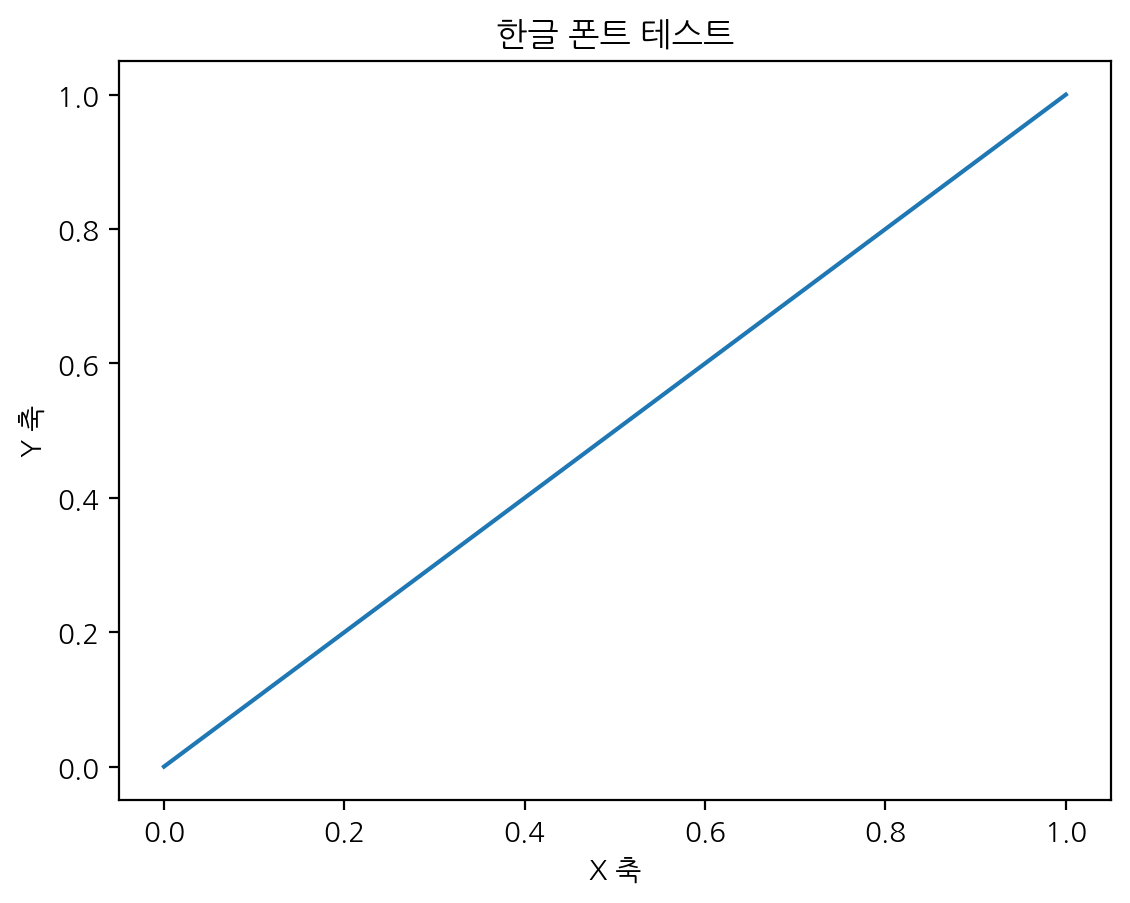

In [40]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import subprocess
import os

# 1. 나눔 폰트 다운로드 및 설치
font_dir = '/usr/share/fonts/truetype/nanum'
os.makedirs(font_dir, exist_ok=True)
subprocess.run(['wget', '-q', 'https://github.com/naver/nanumfont/releases/latest/download/NanumFont_TTF.zip'])
subprocess.run(['unzip', '-o', 'NanumFont_TTF.zip', '-d', font_dir])
subprocess.run(['rm', 'NanumFont_TTF.zip'])

# 2. 폰트 캐시 리빌드
subprocess.run(['fc-cache', '-fv'])

# 3. matplotlib에 폰트 적용
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams['font.family'] = 'NanumGothic'

# 4. 폰트 적용 확인
print(f"적용된 폰트: {plt.rcParams['font.family']}")

# 5. 테스트 그래프 그리기
plt.figure()
plt.plot([0, 1], [0, 1])
plt.title('한글 폰트 테스트')
plt.xlabel('X 축')
plt.ylabel('Y 축')
plt.show()


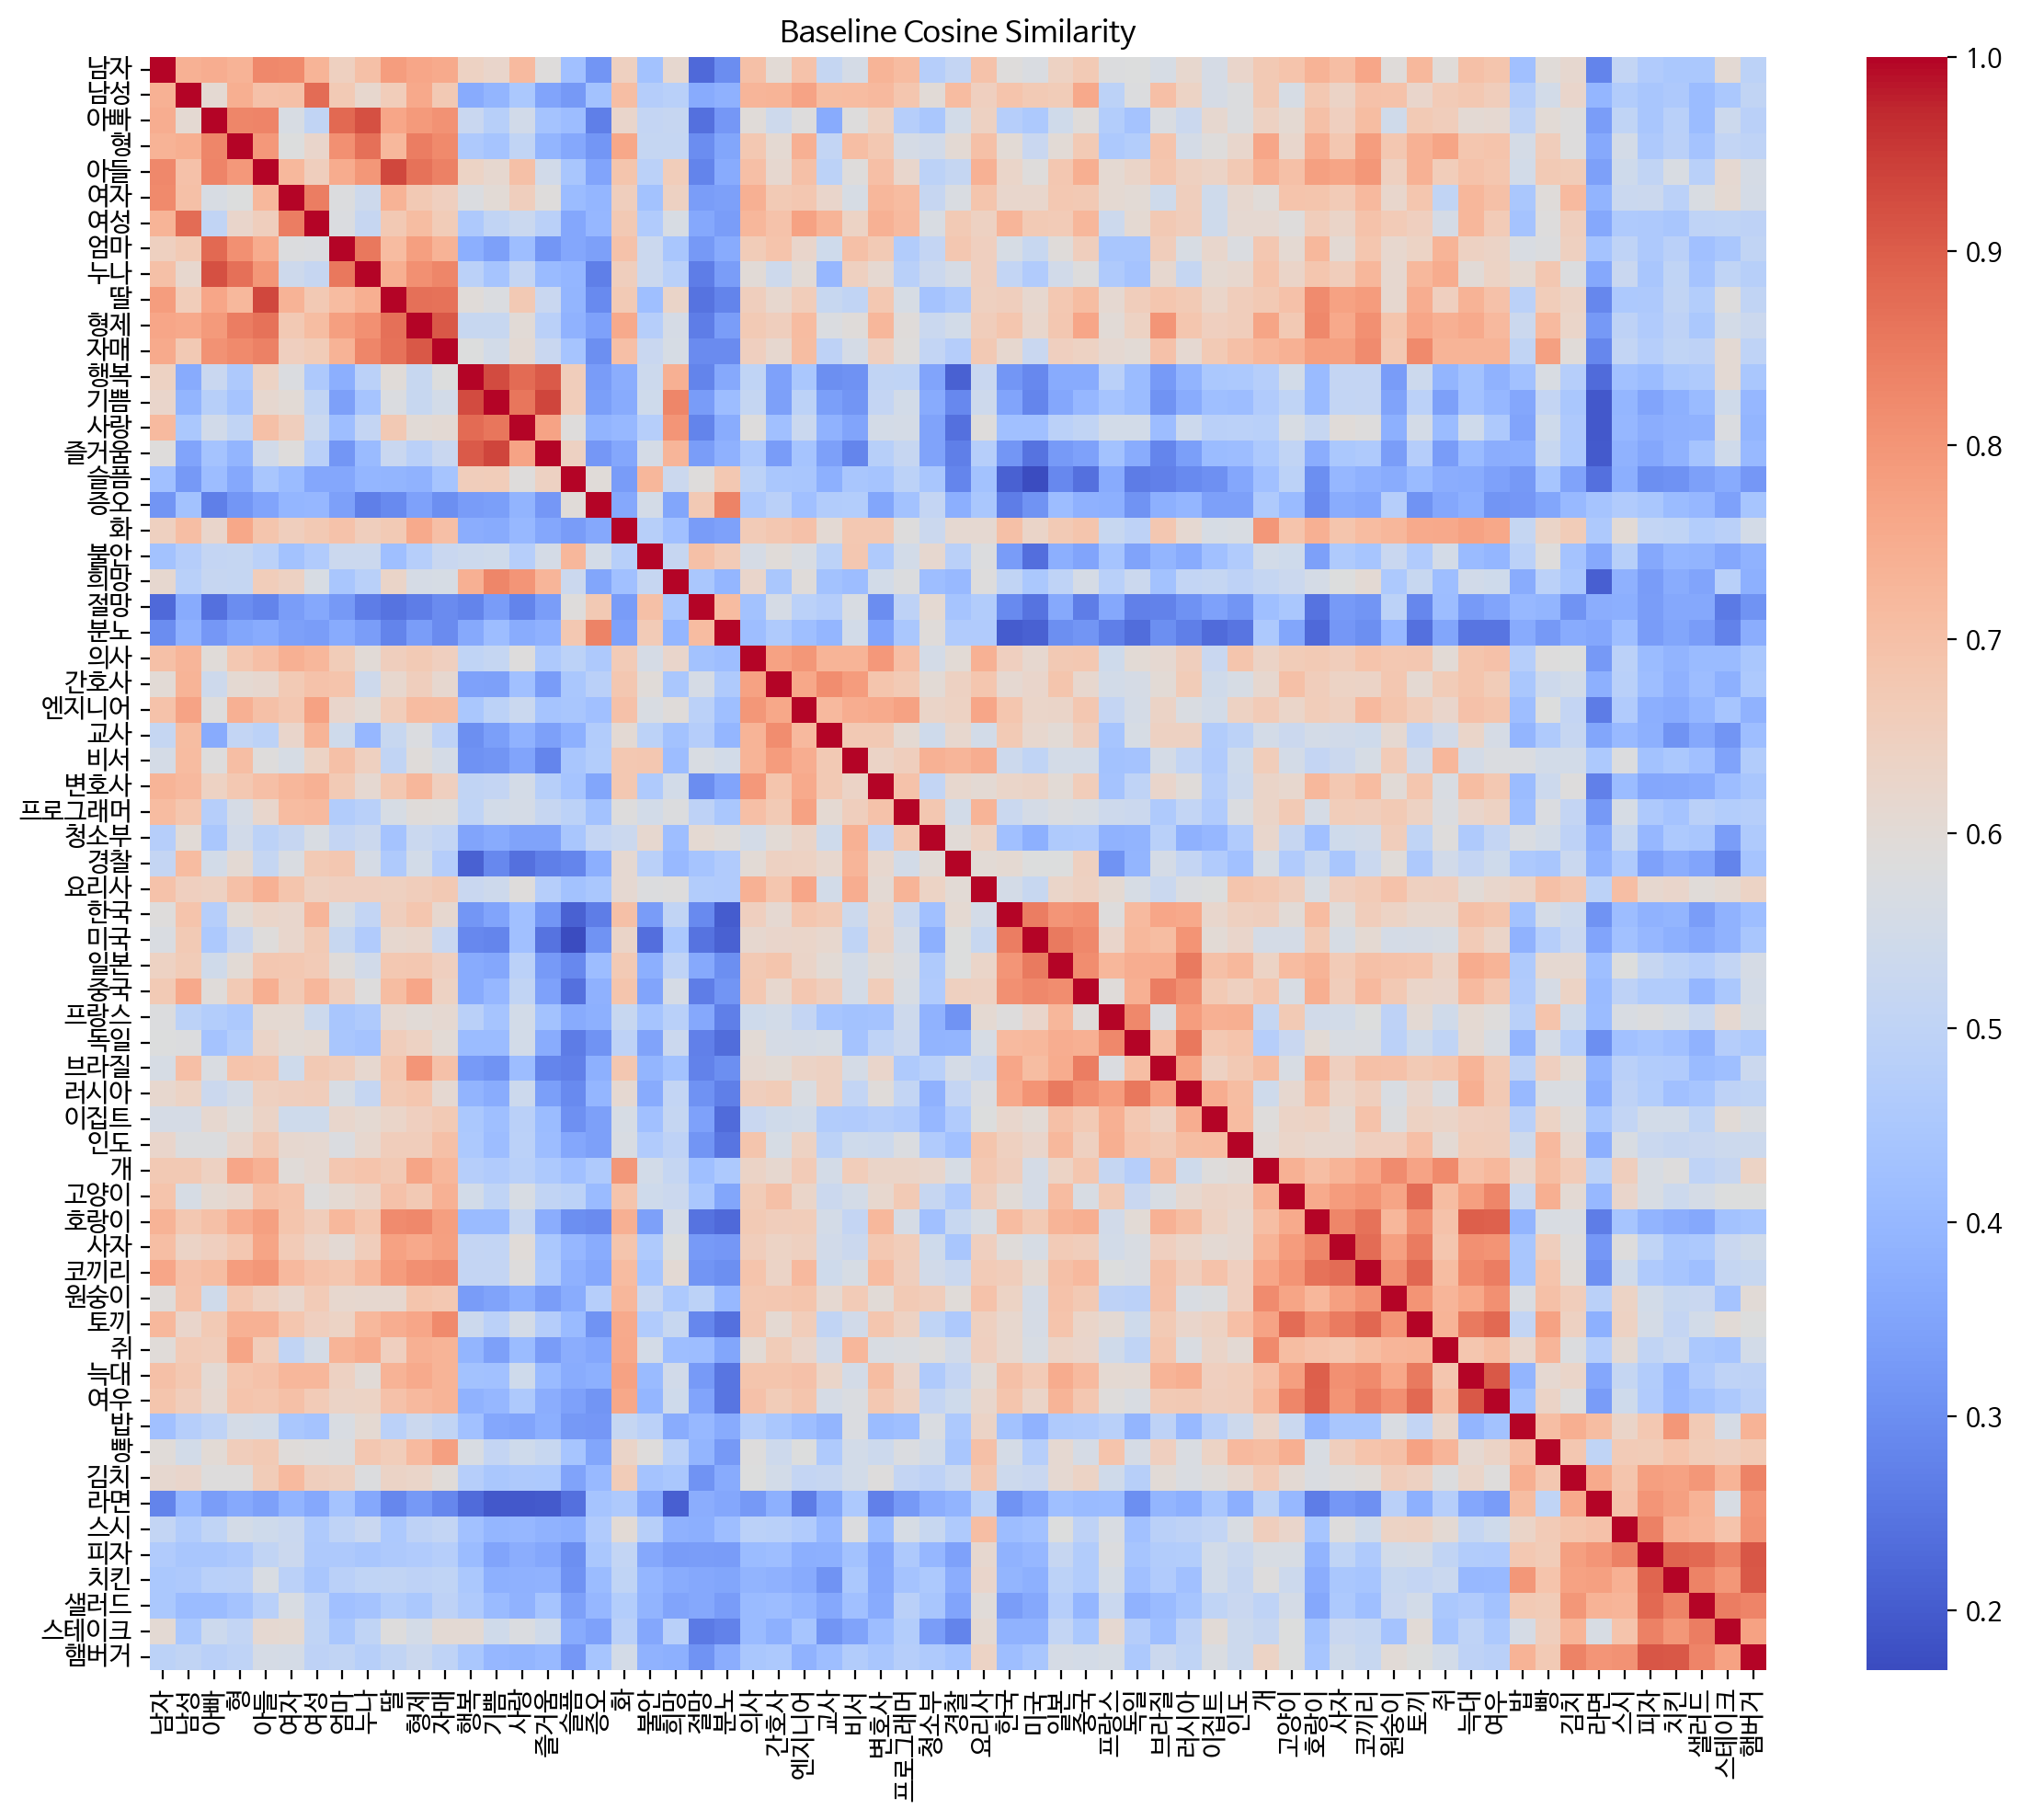

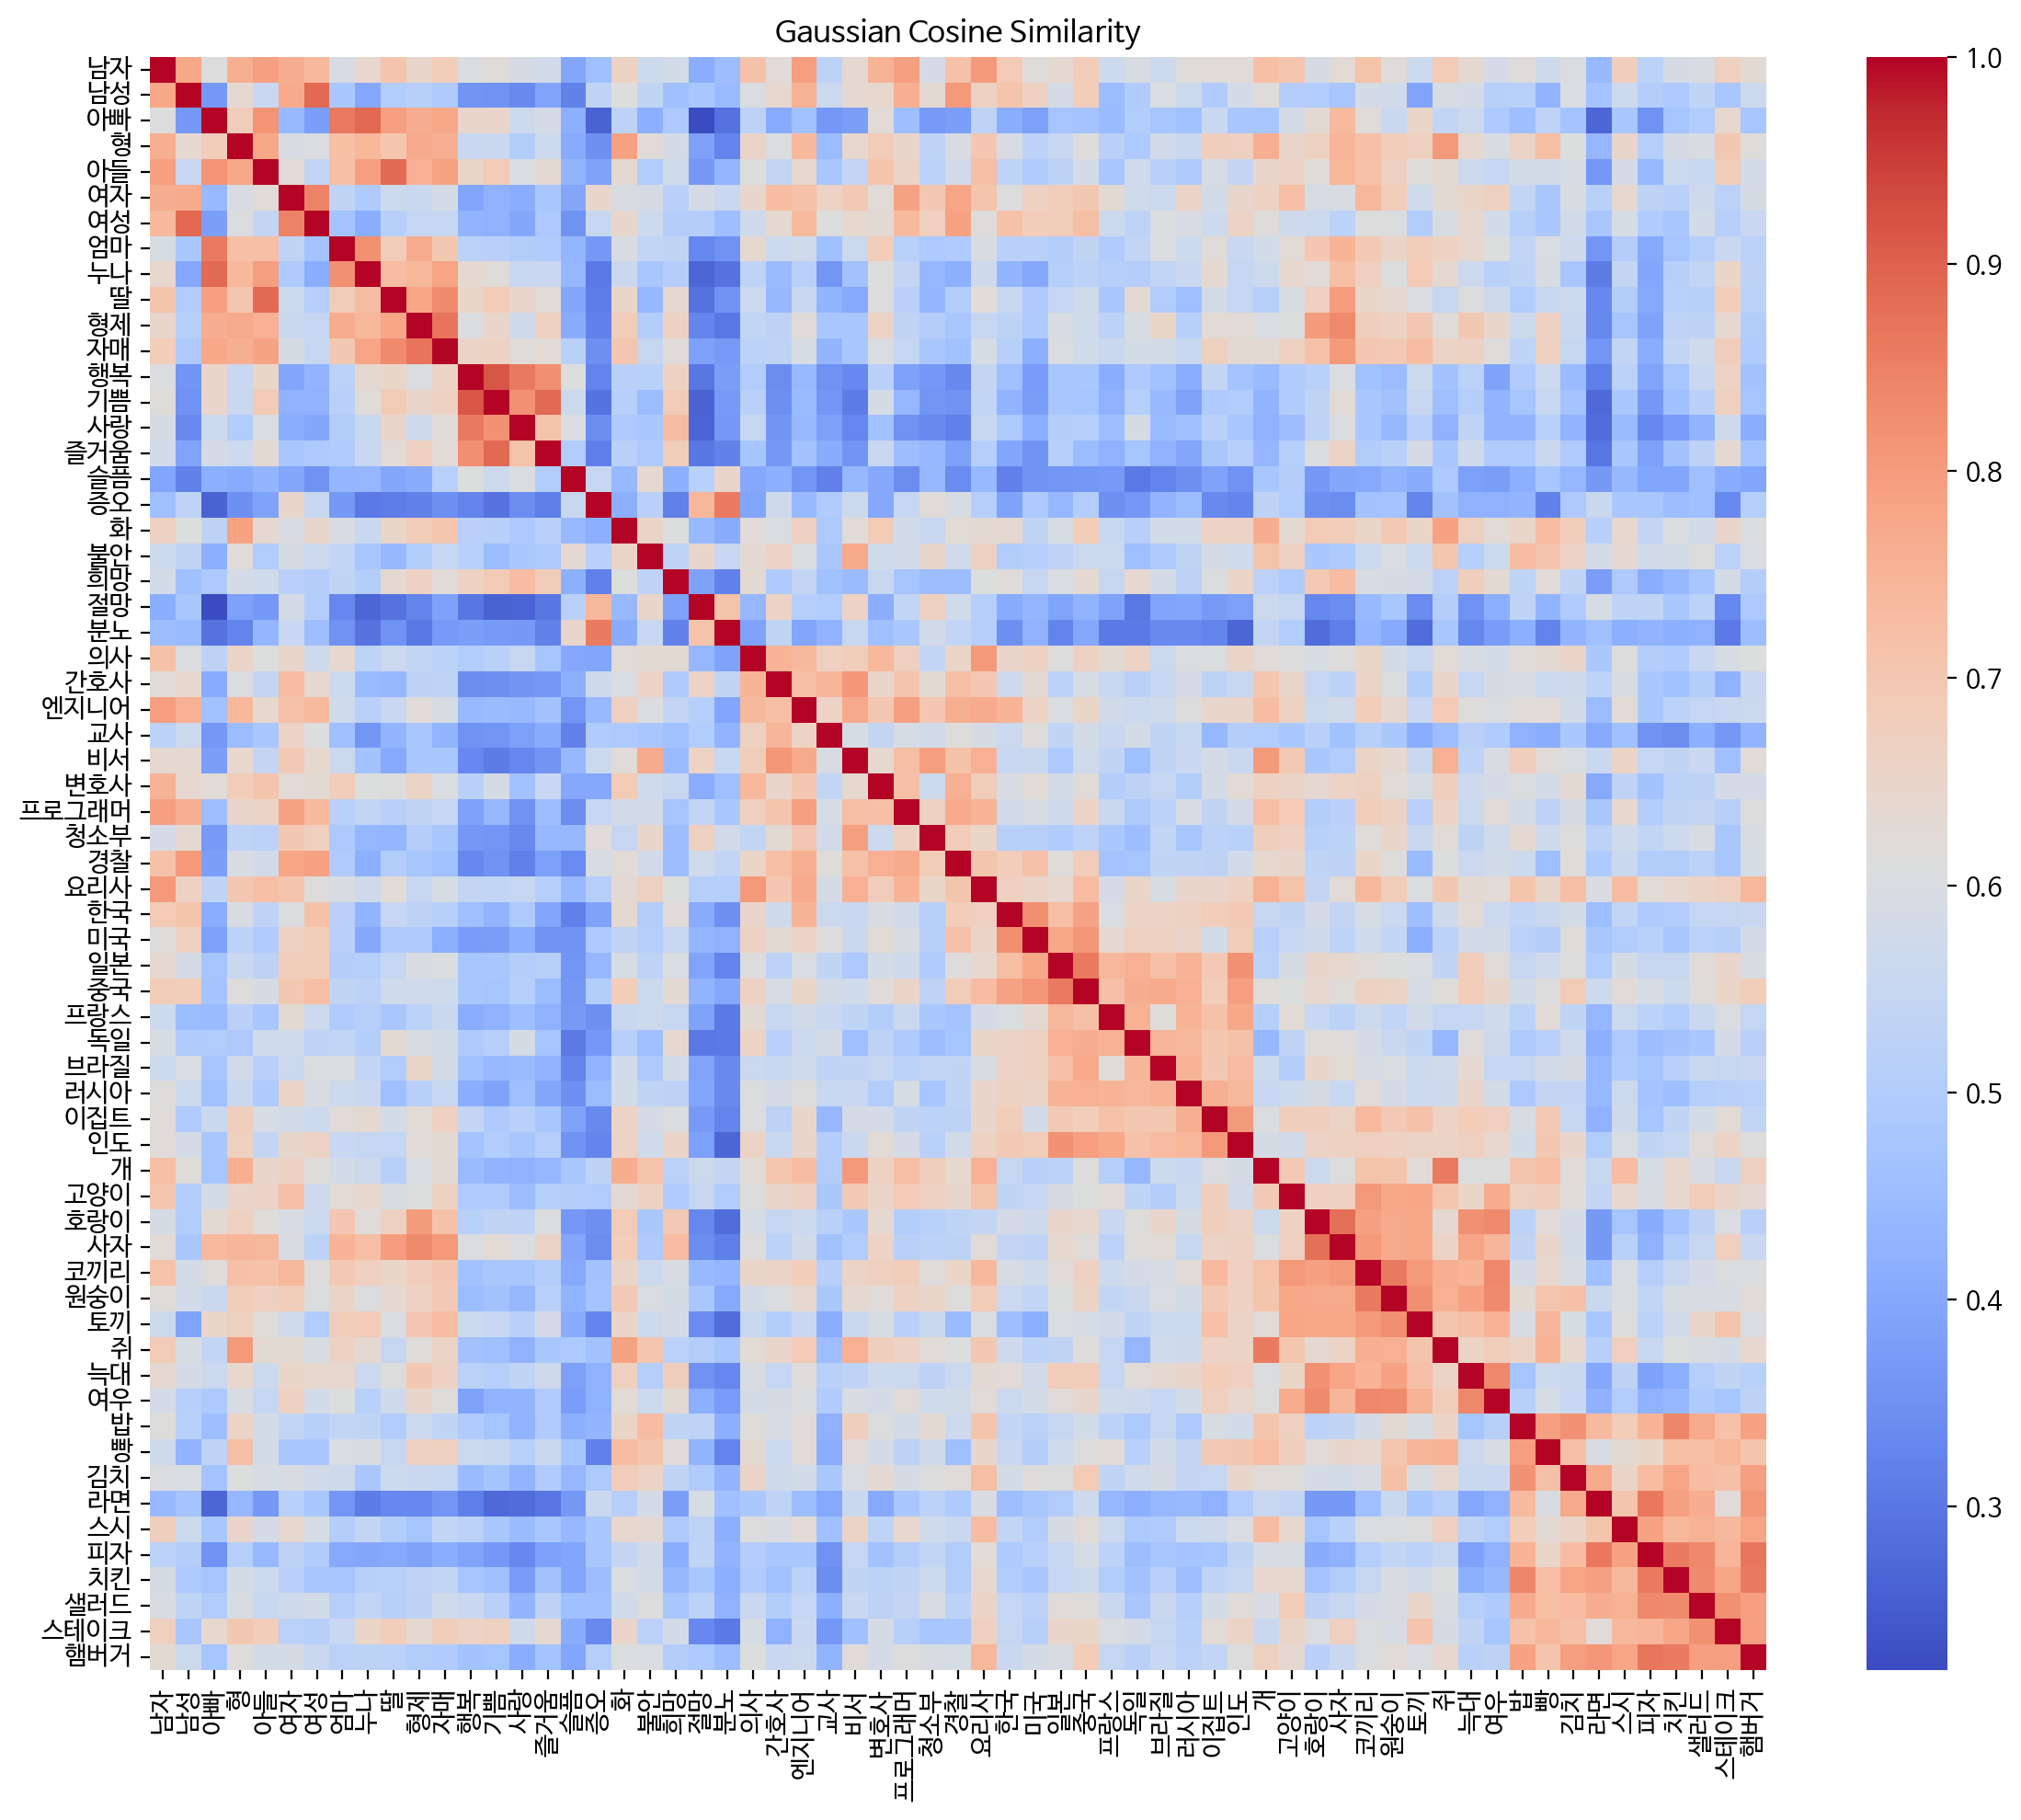

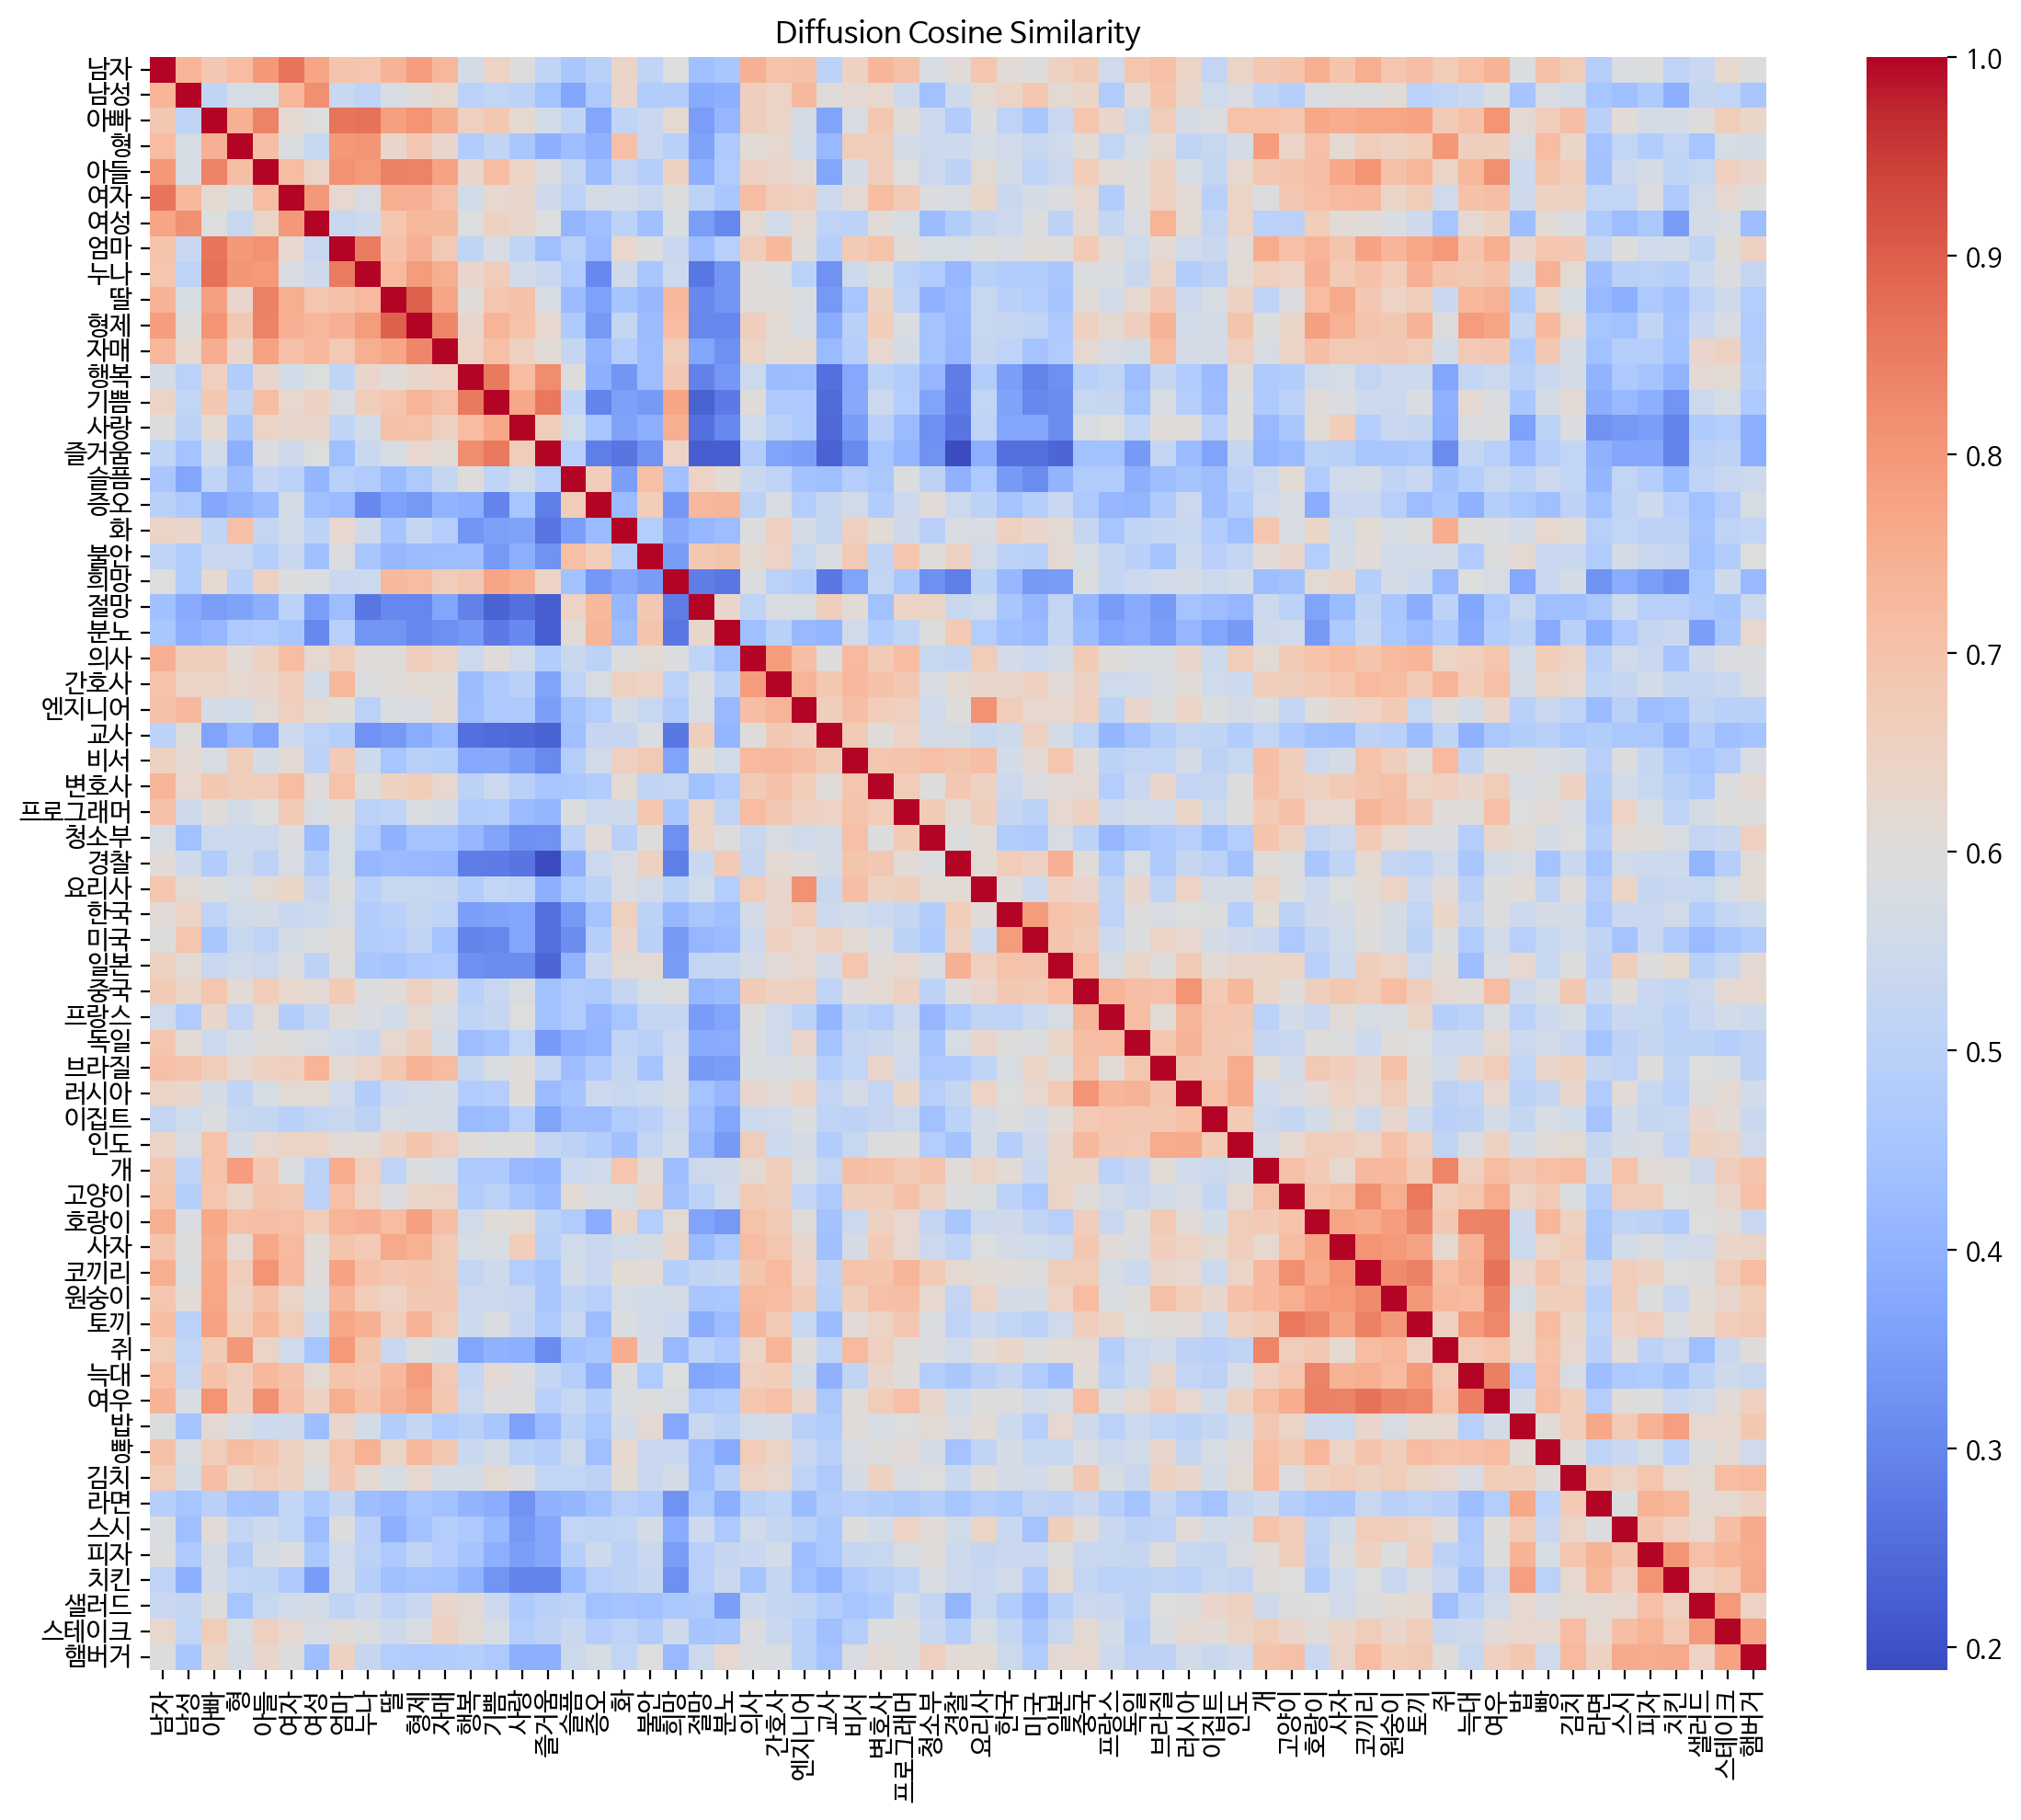

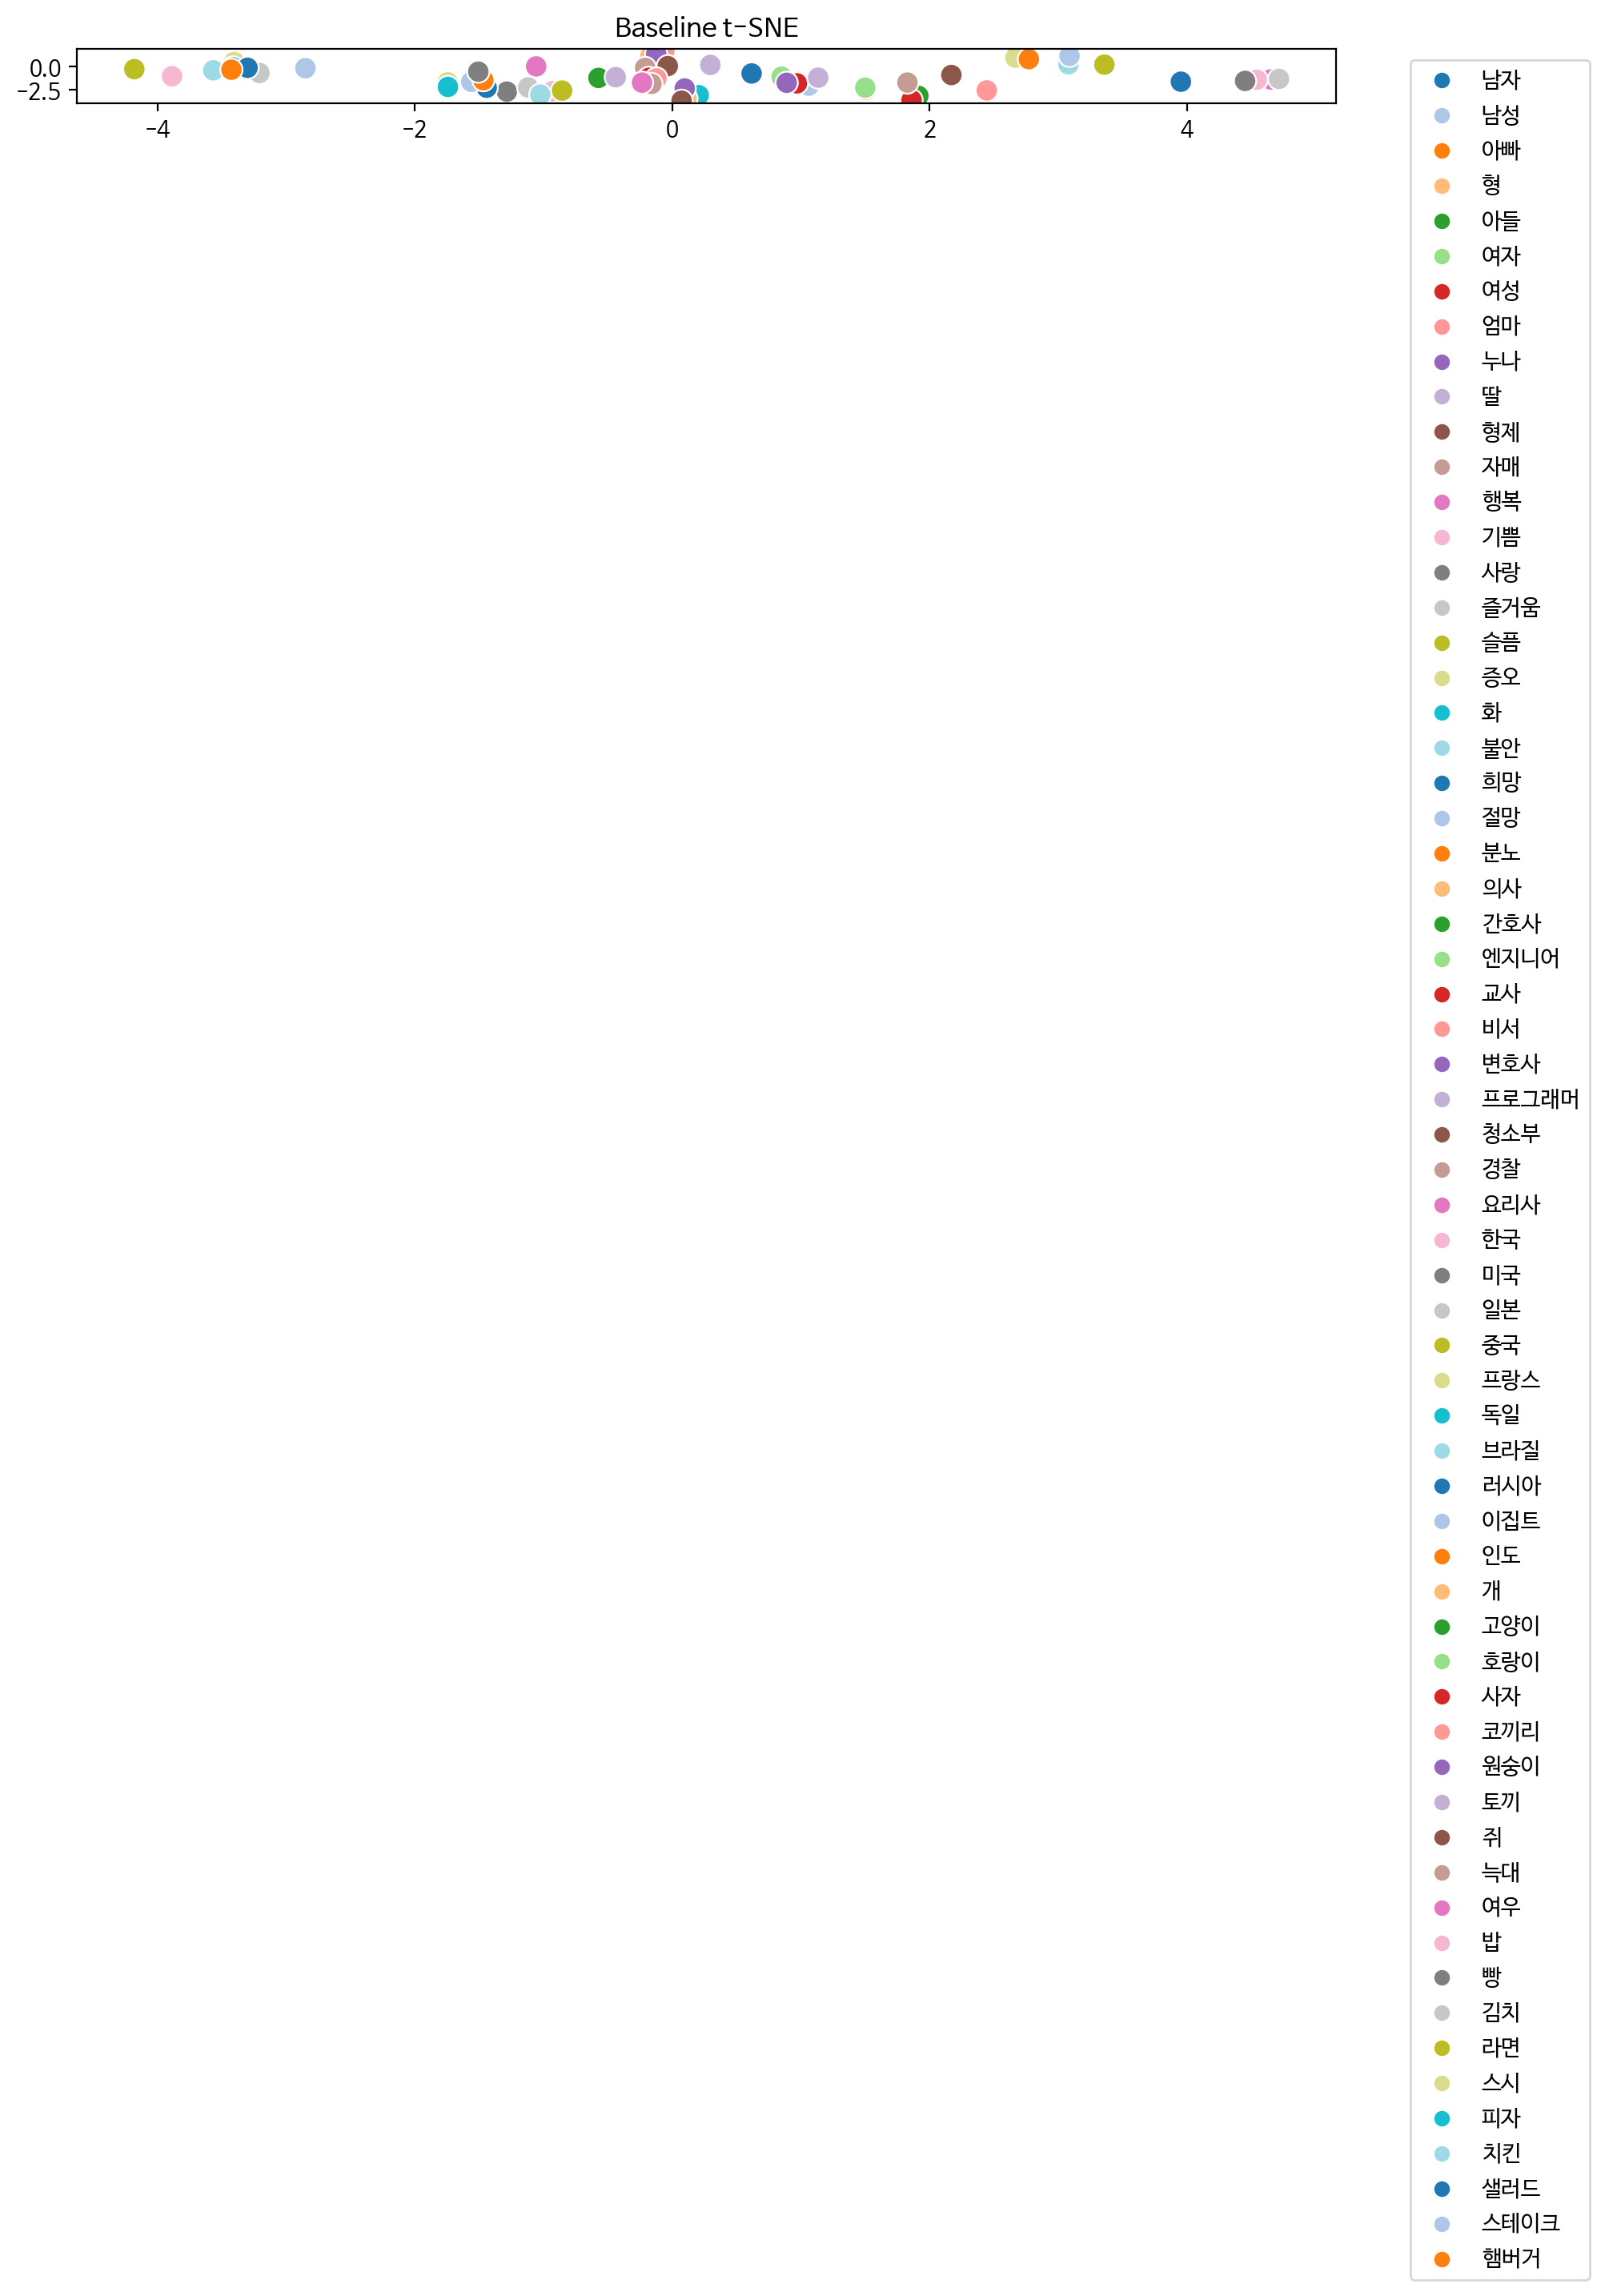

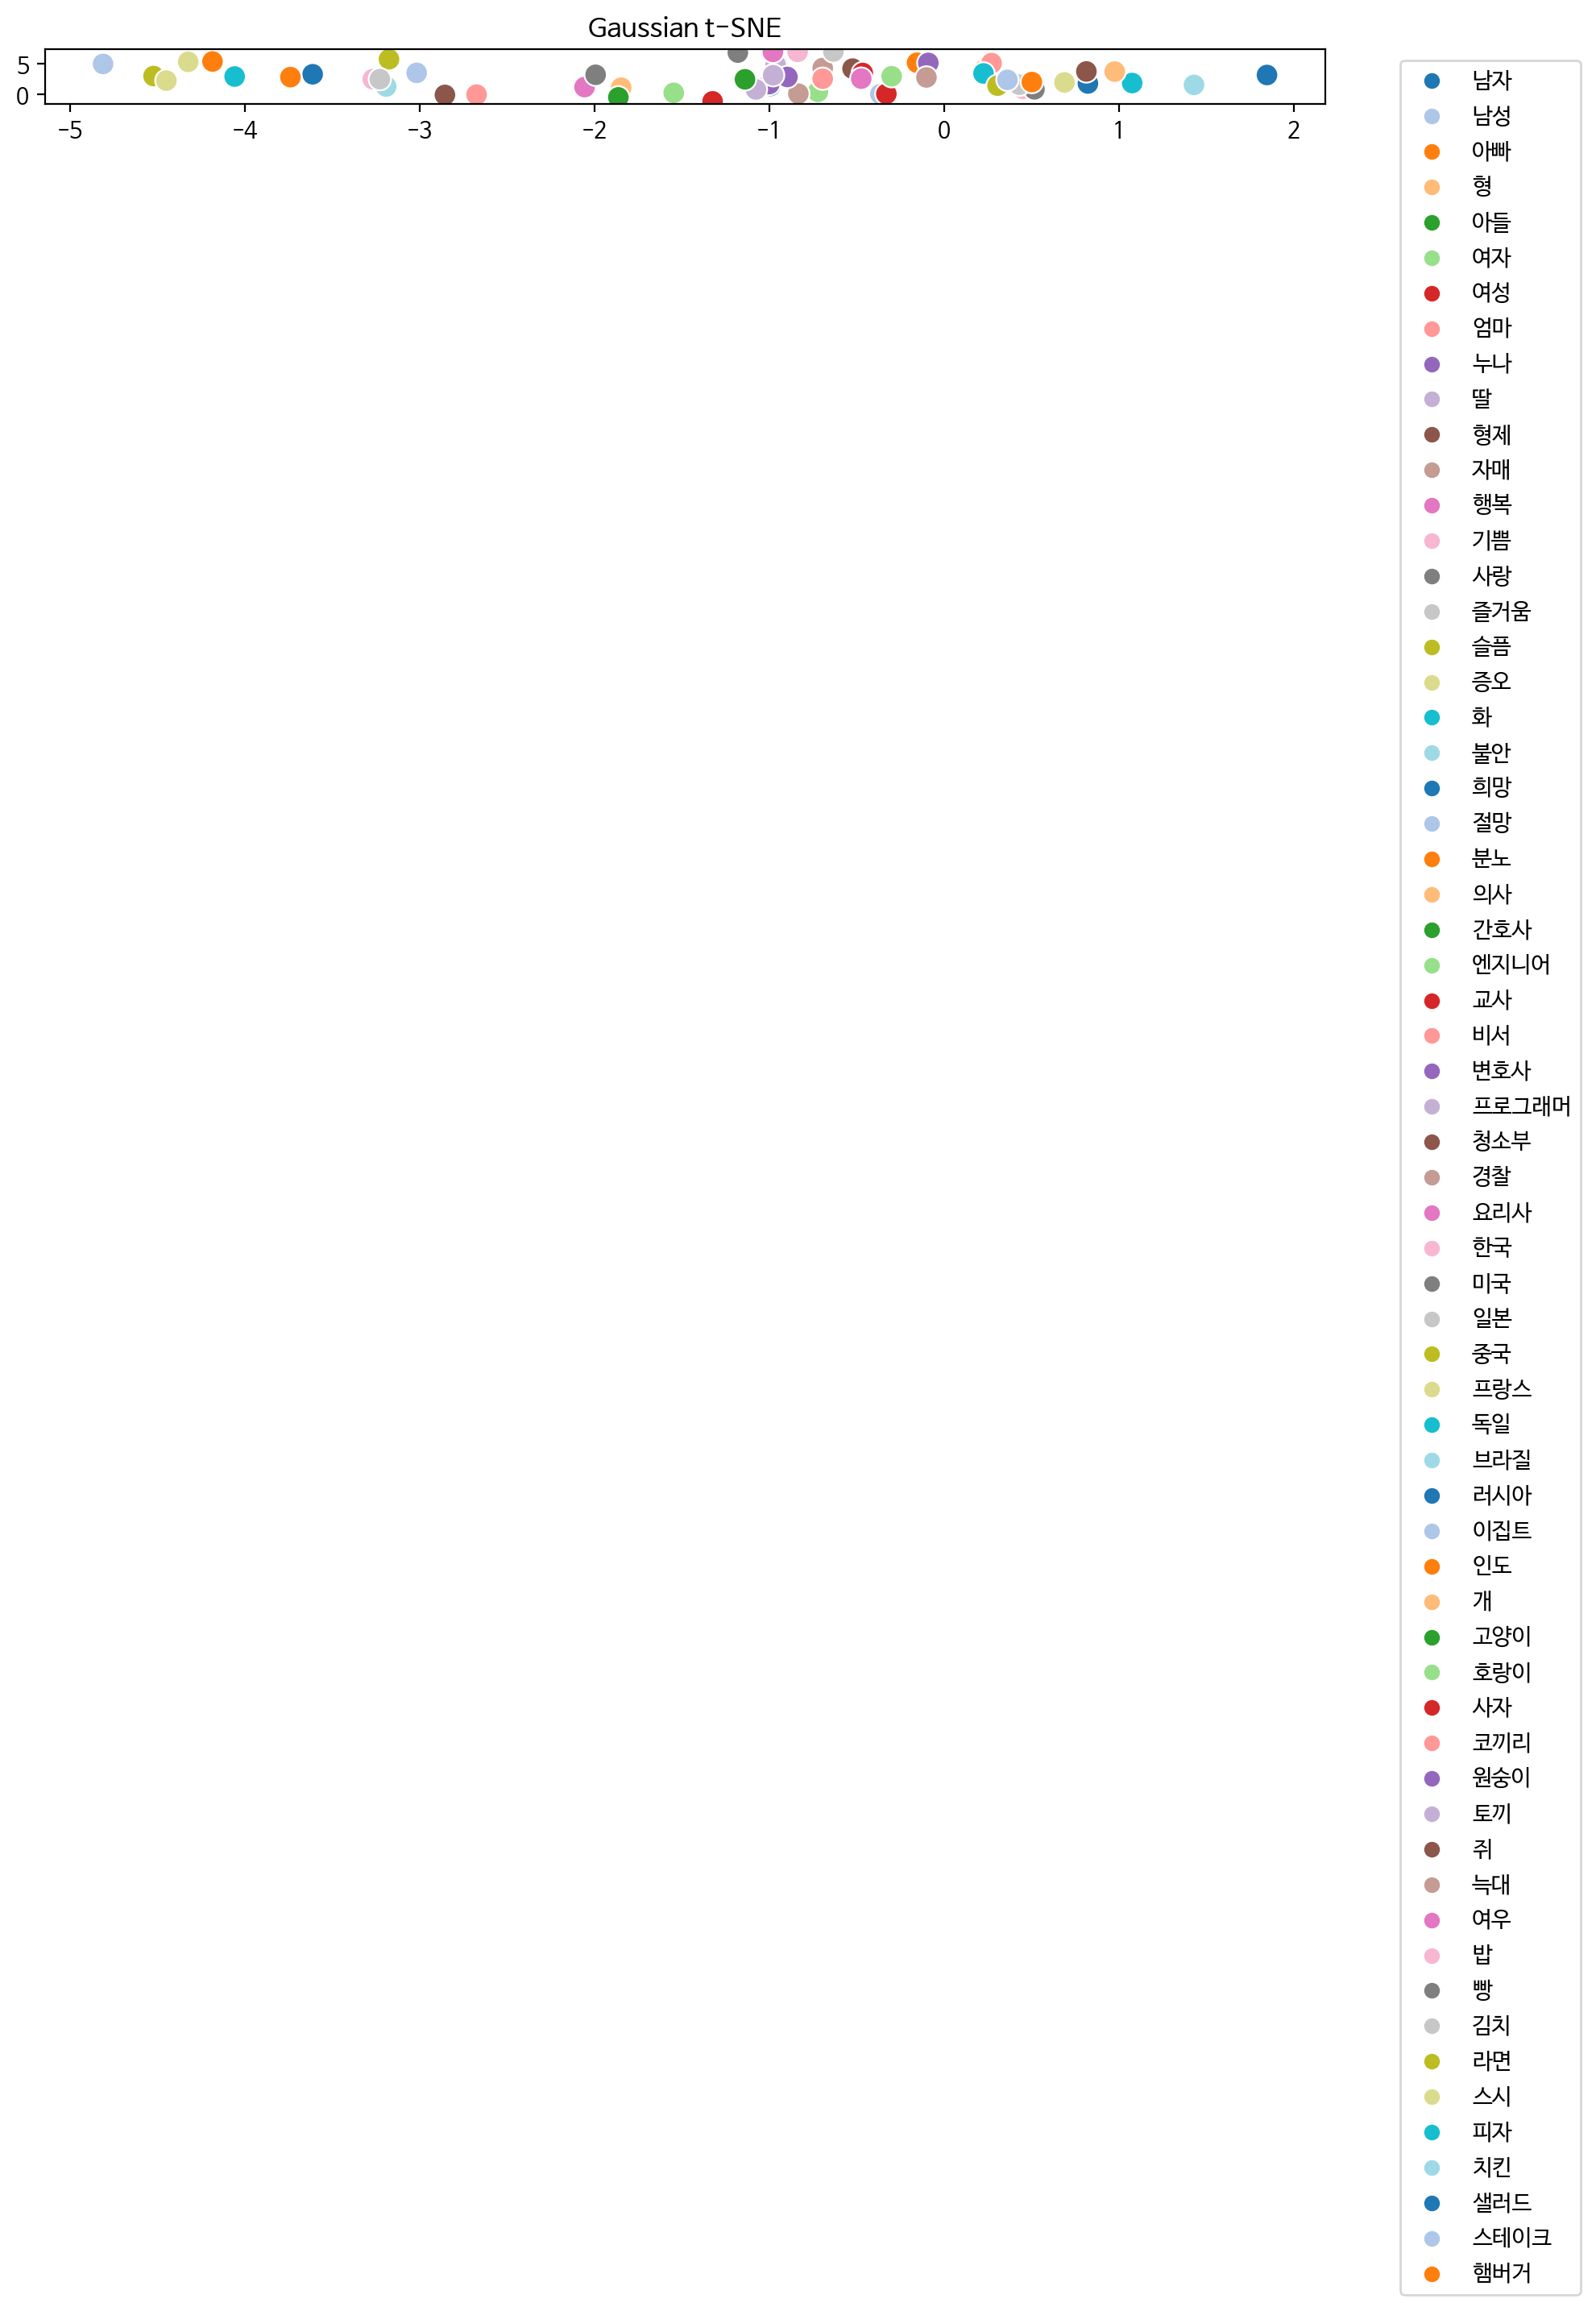

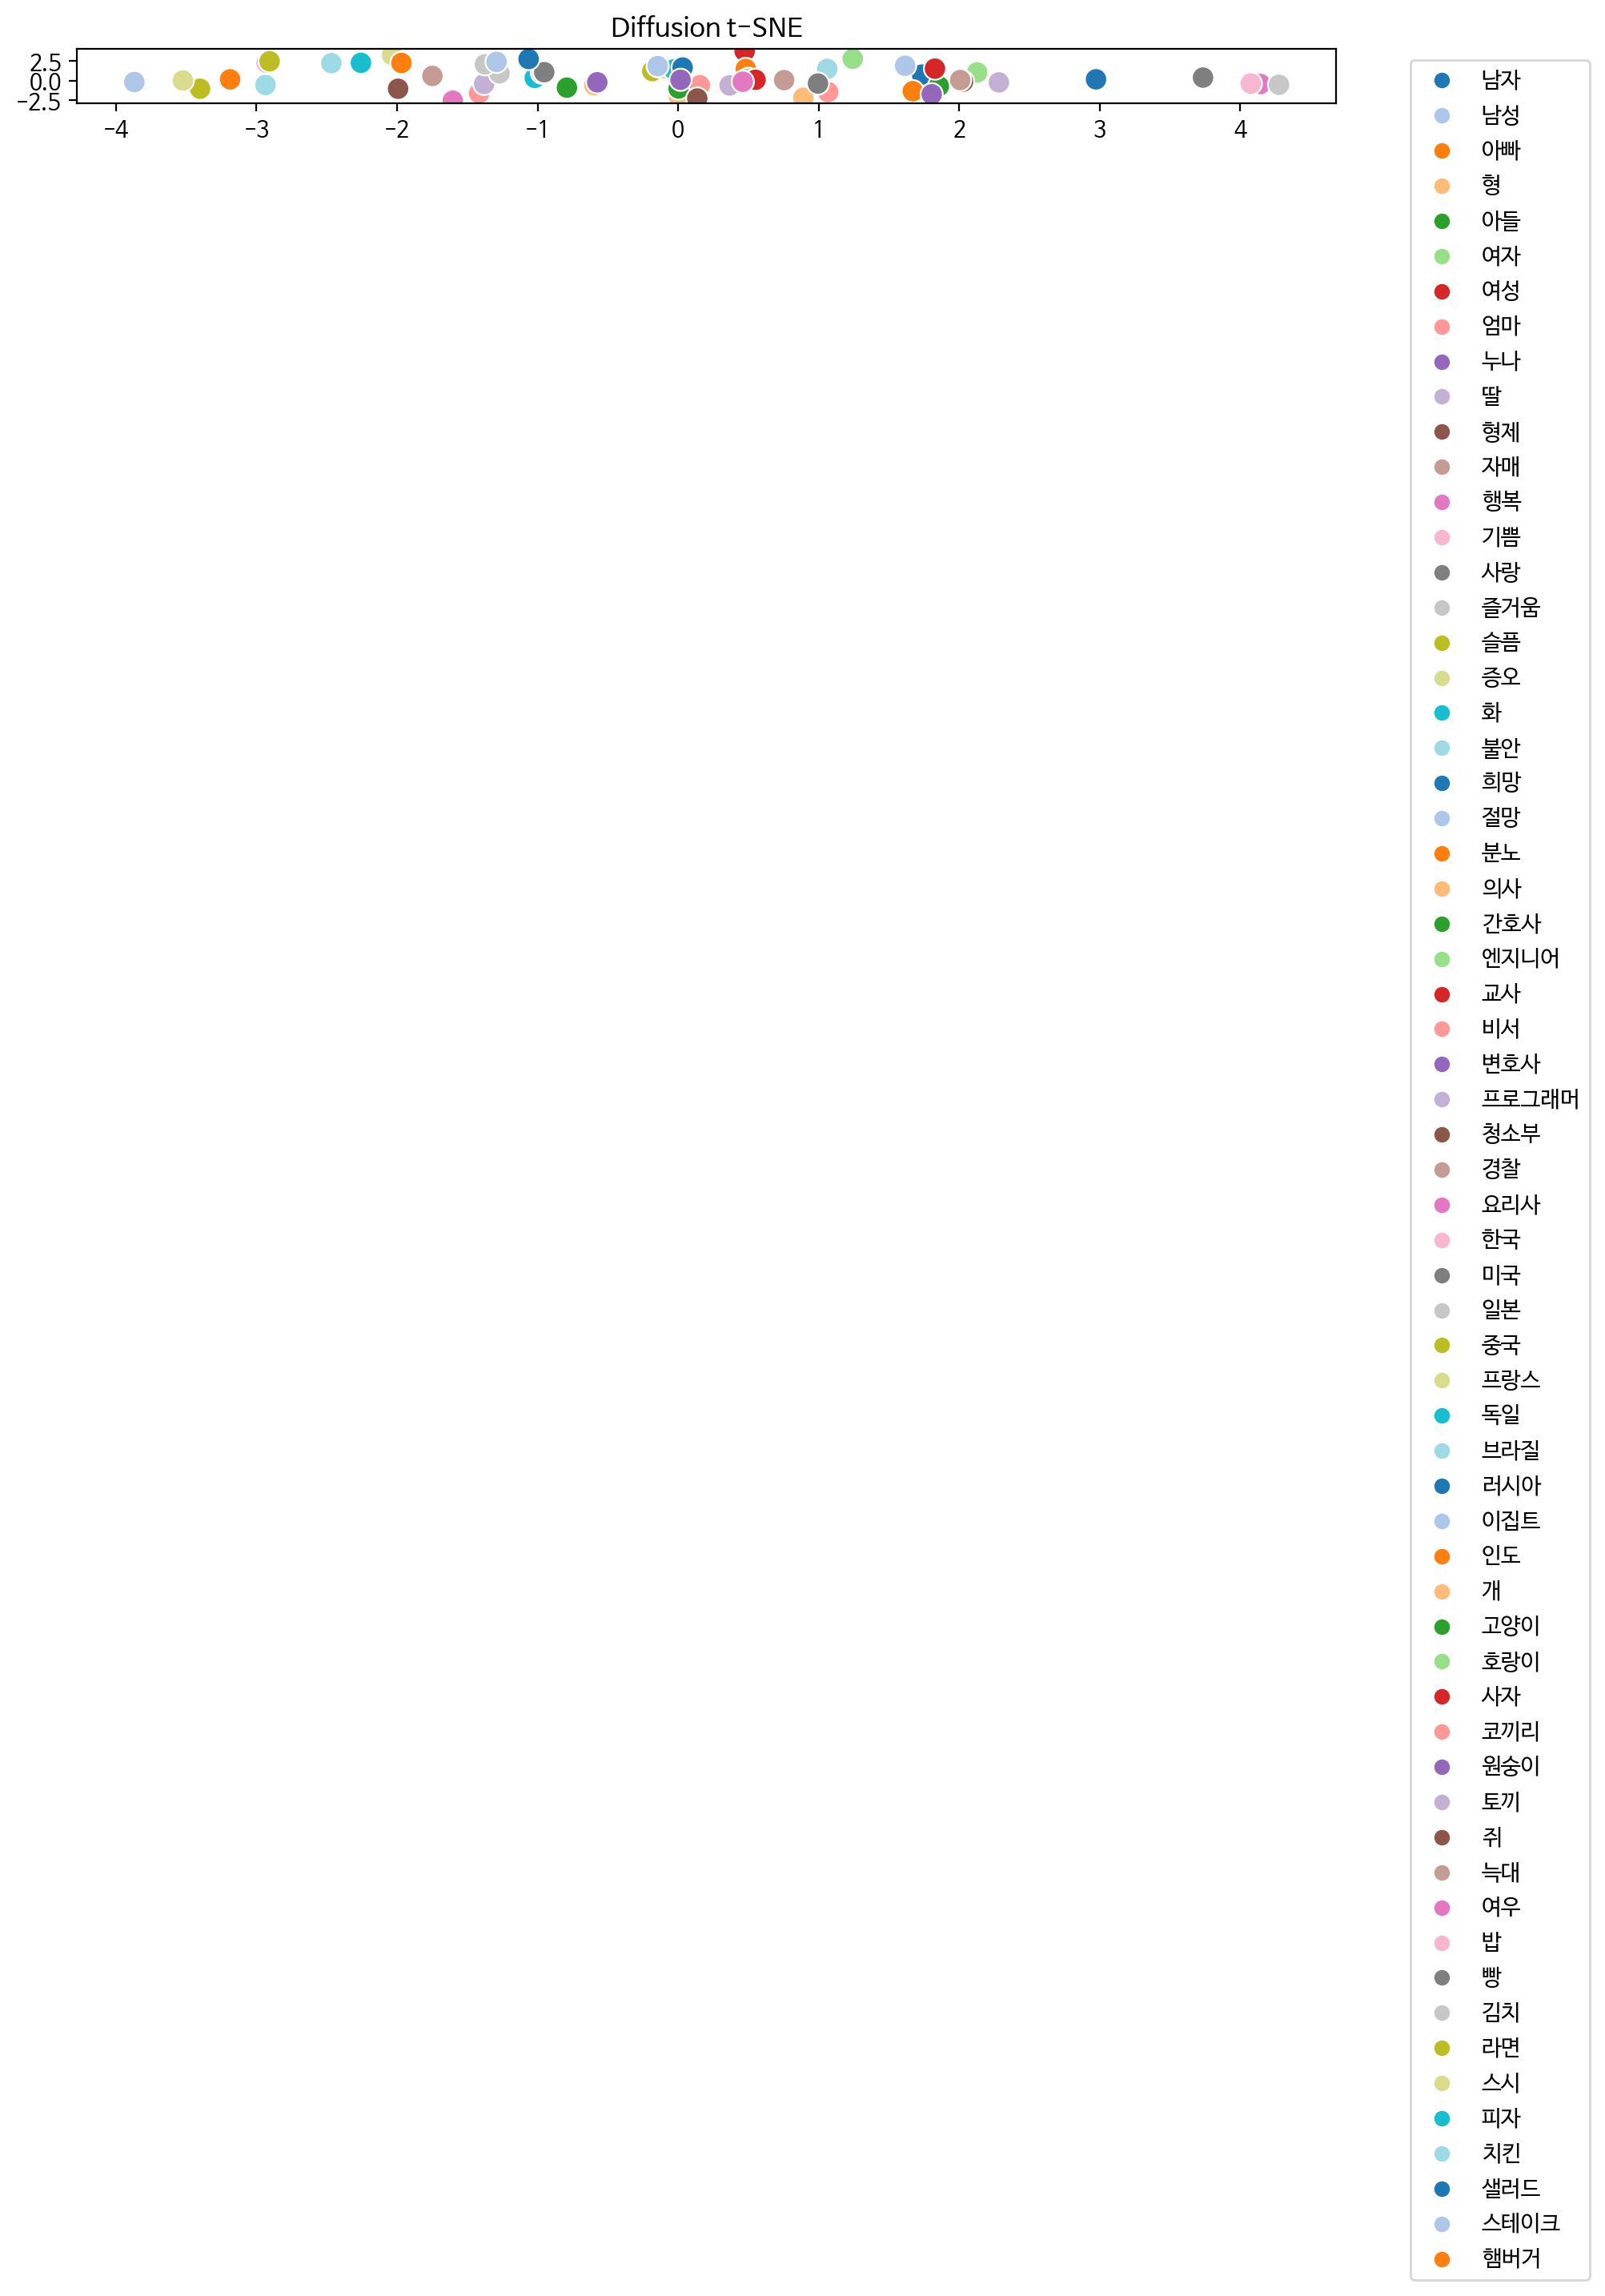

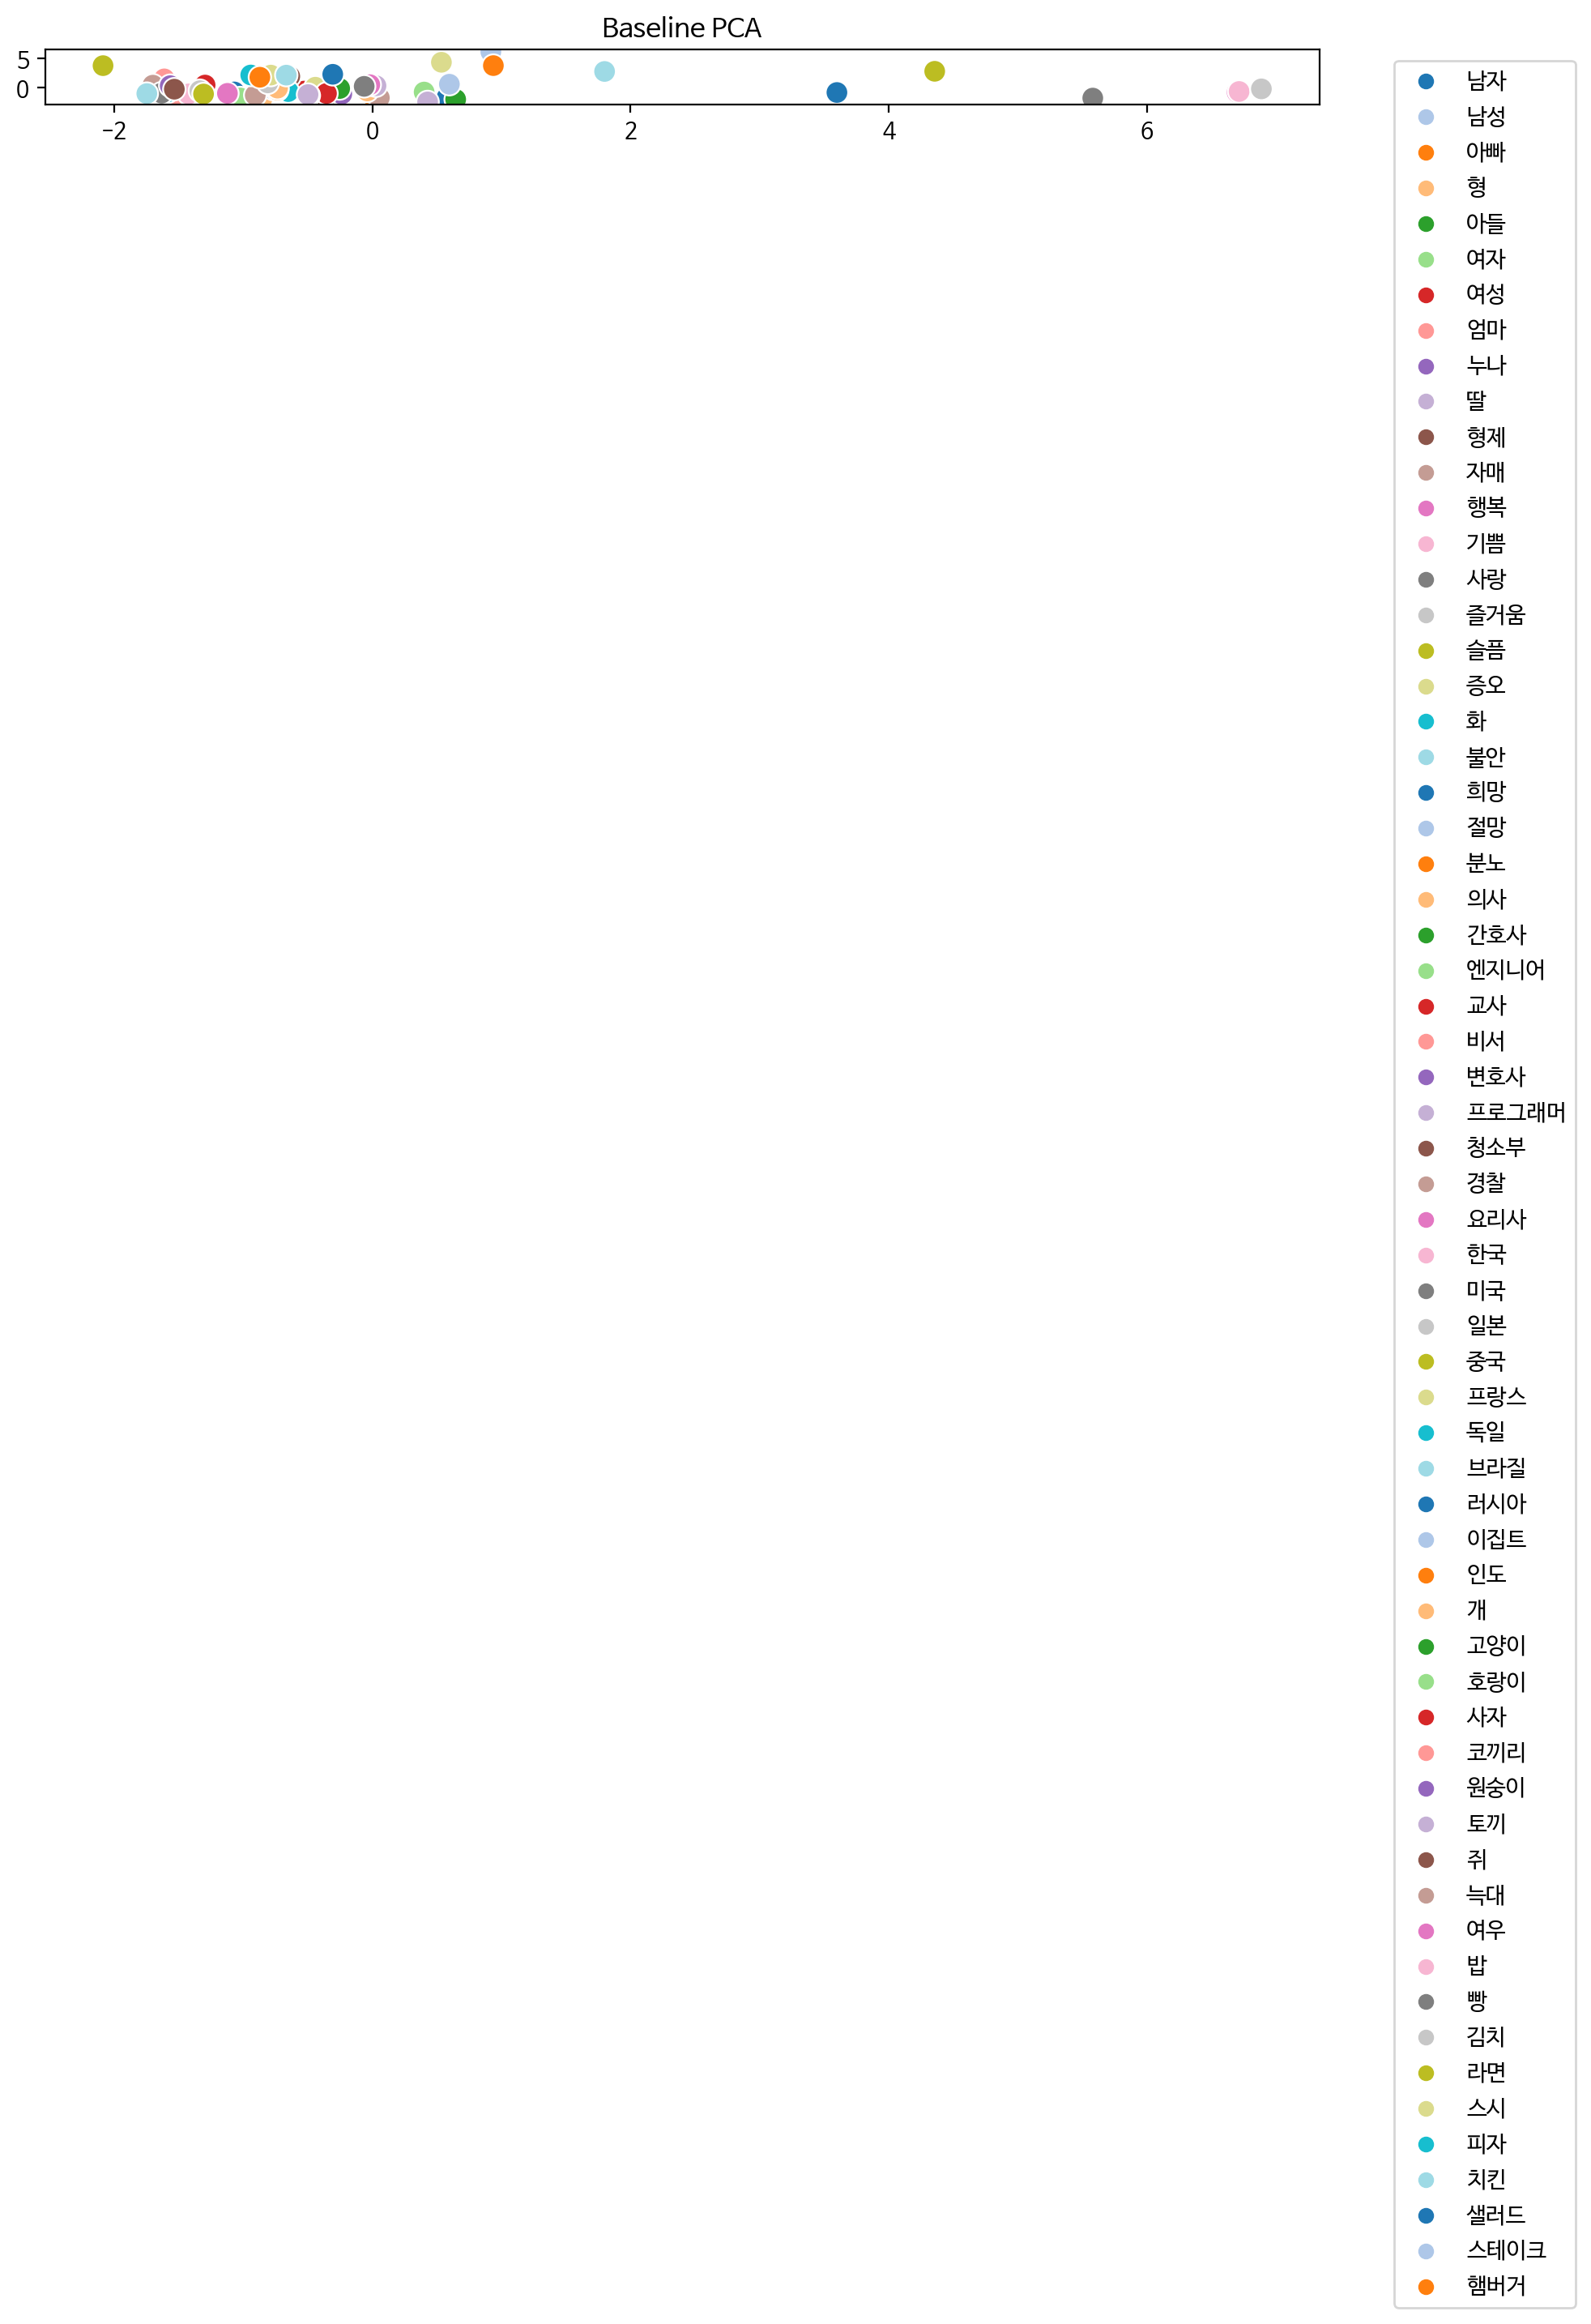

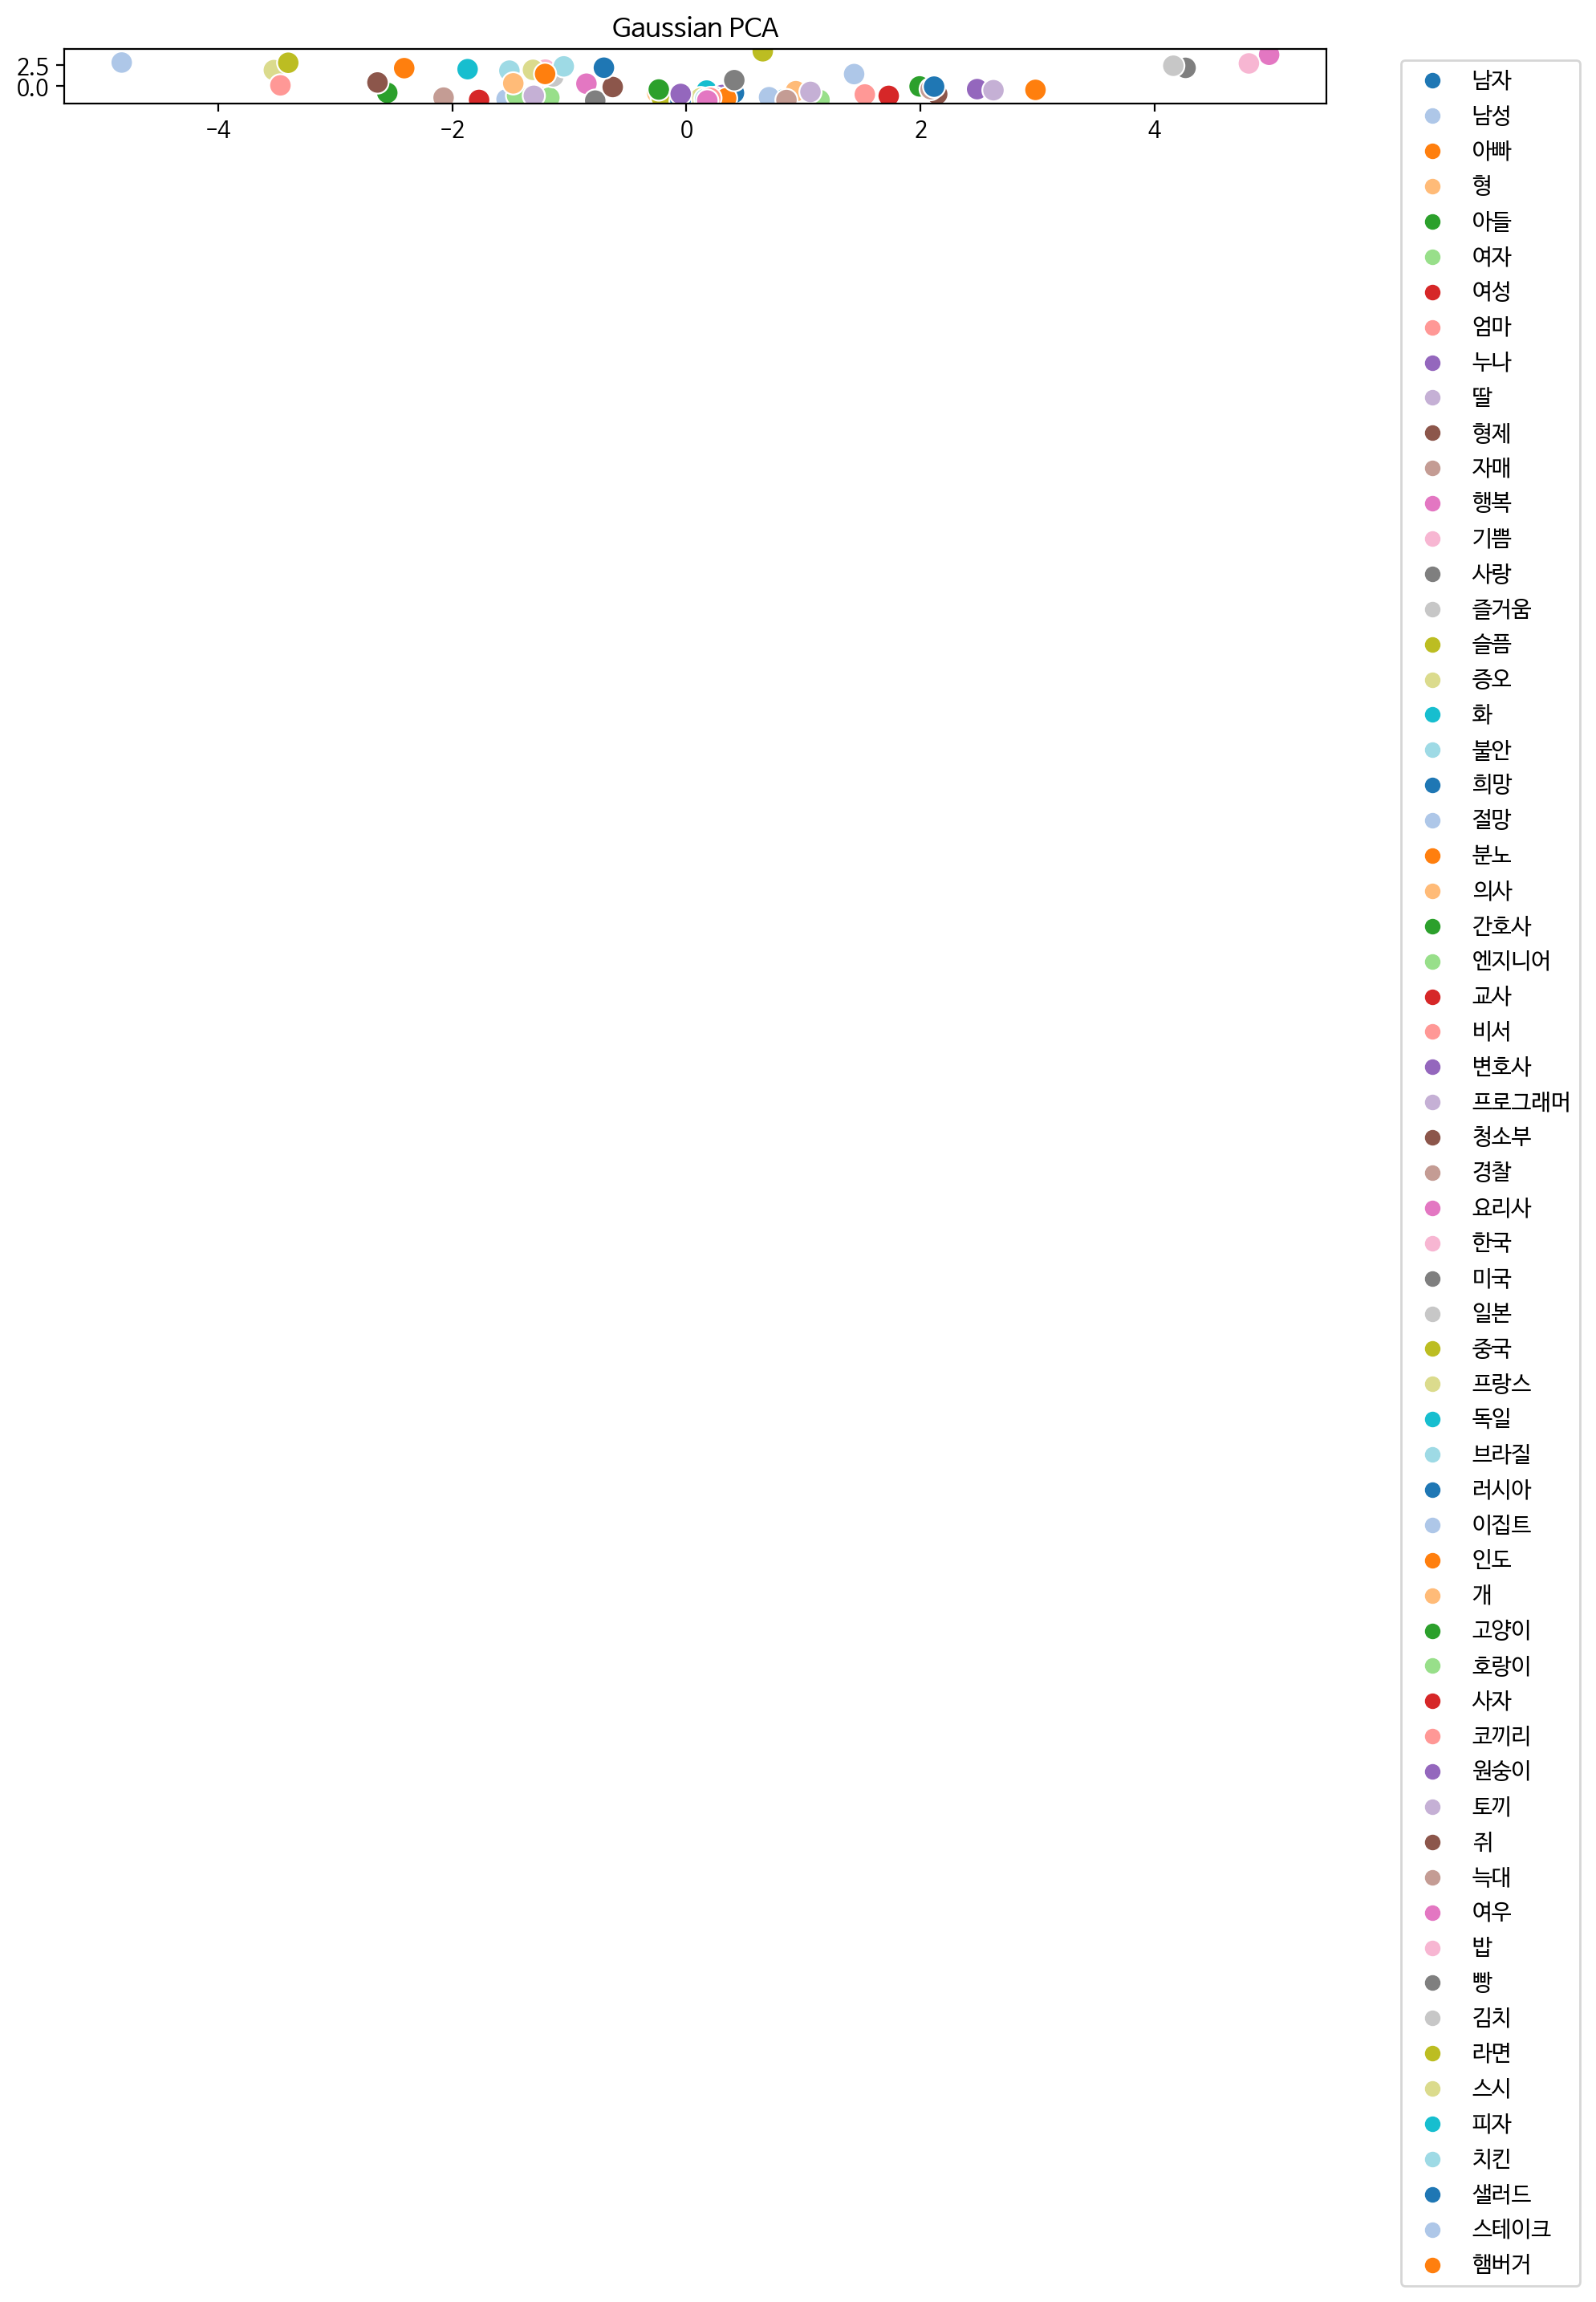

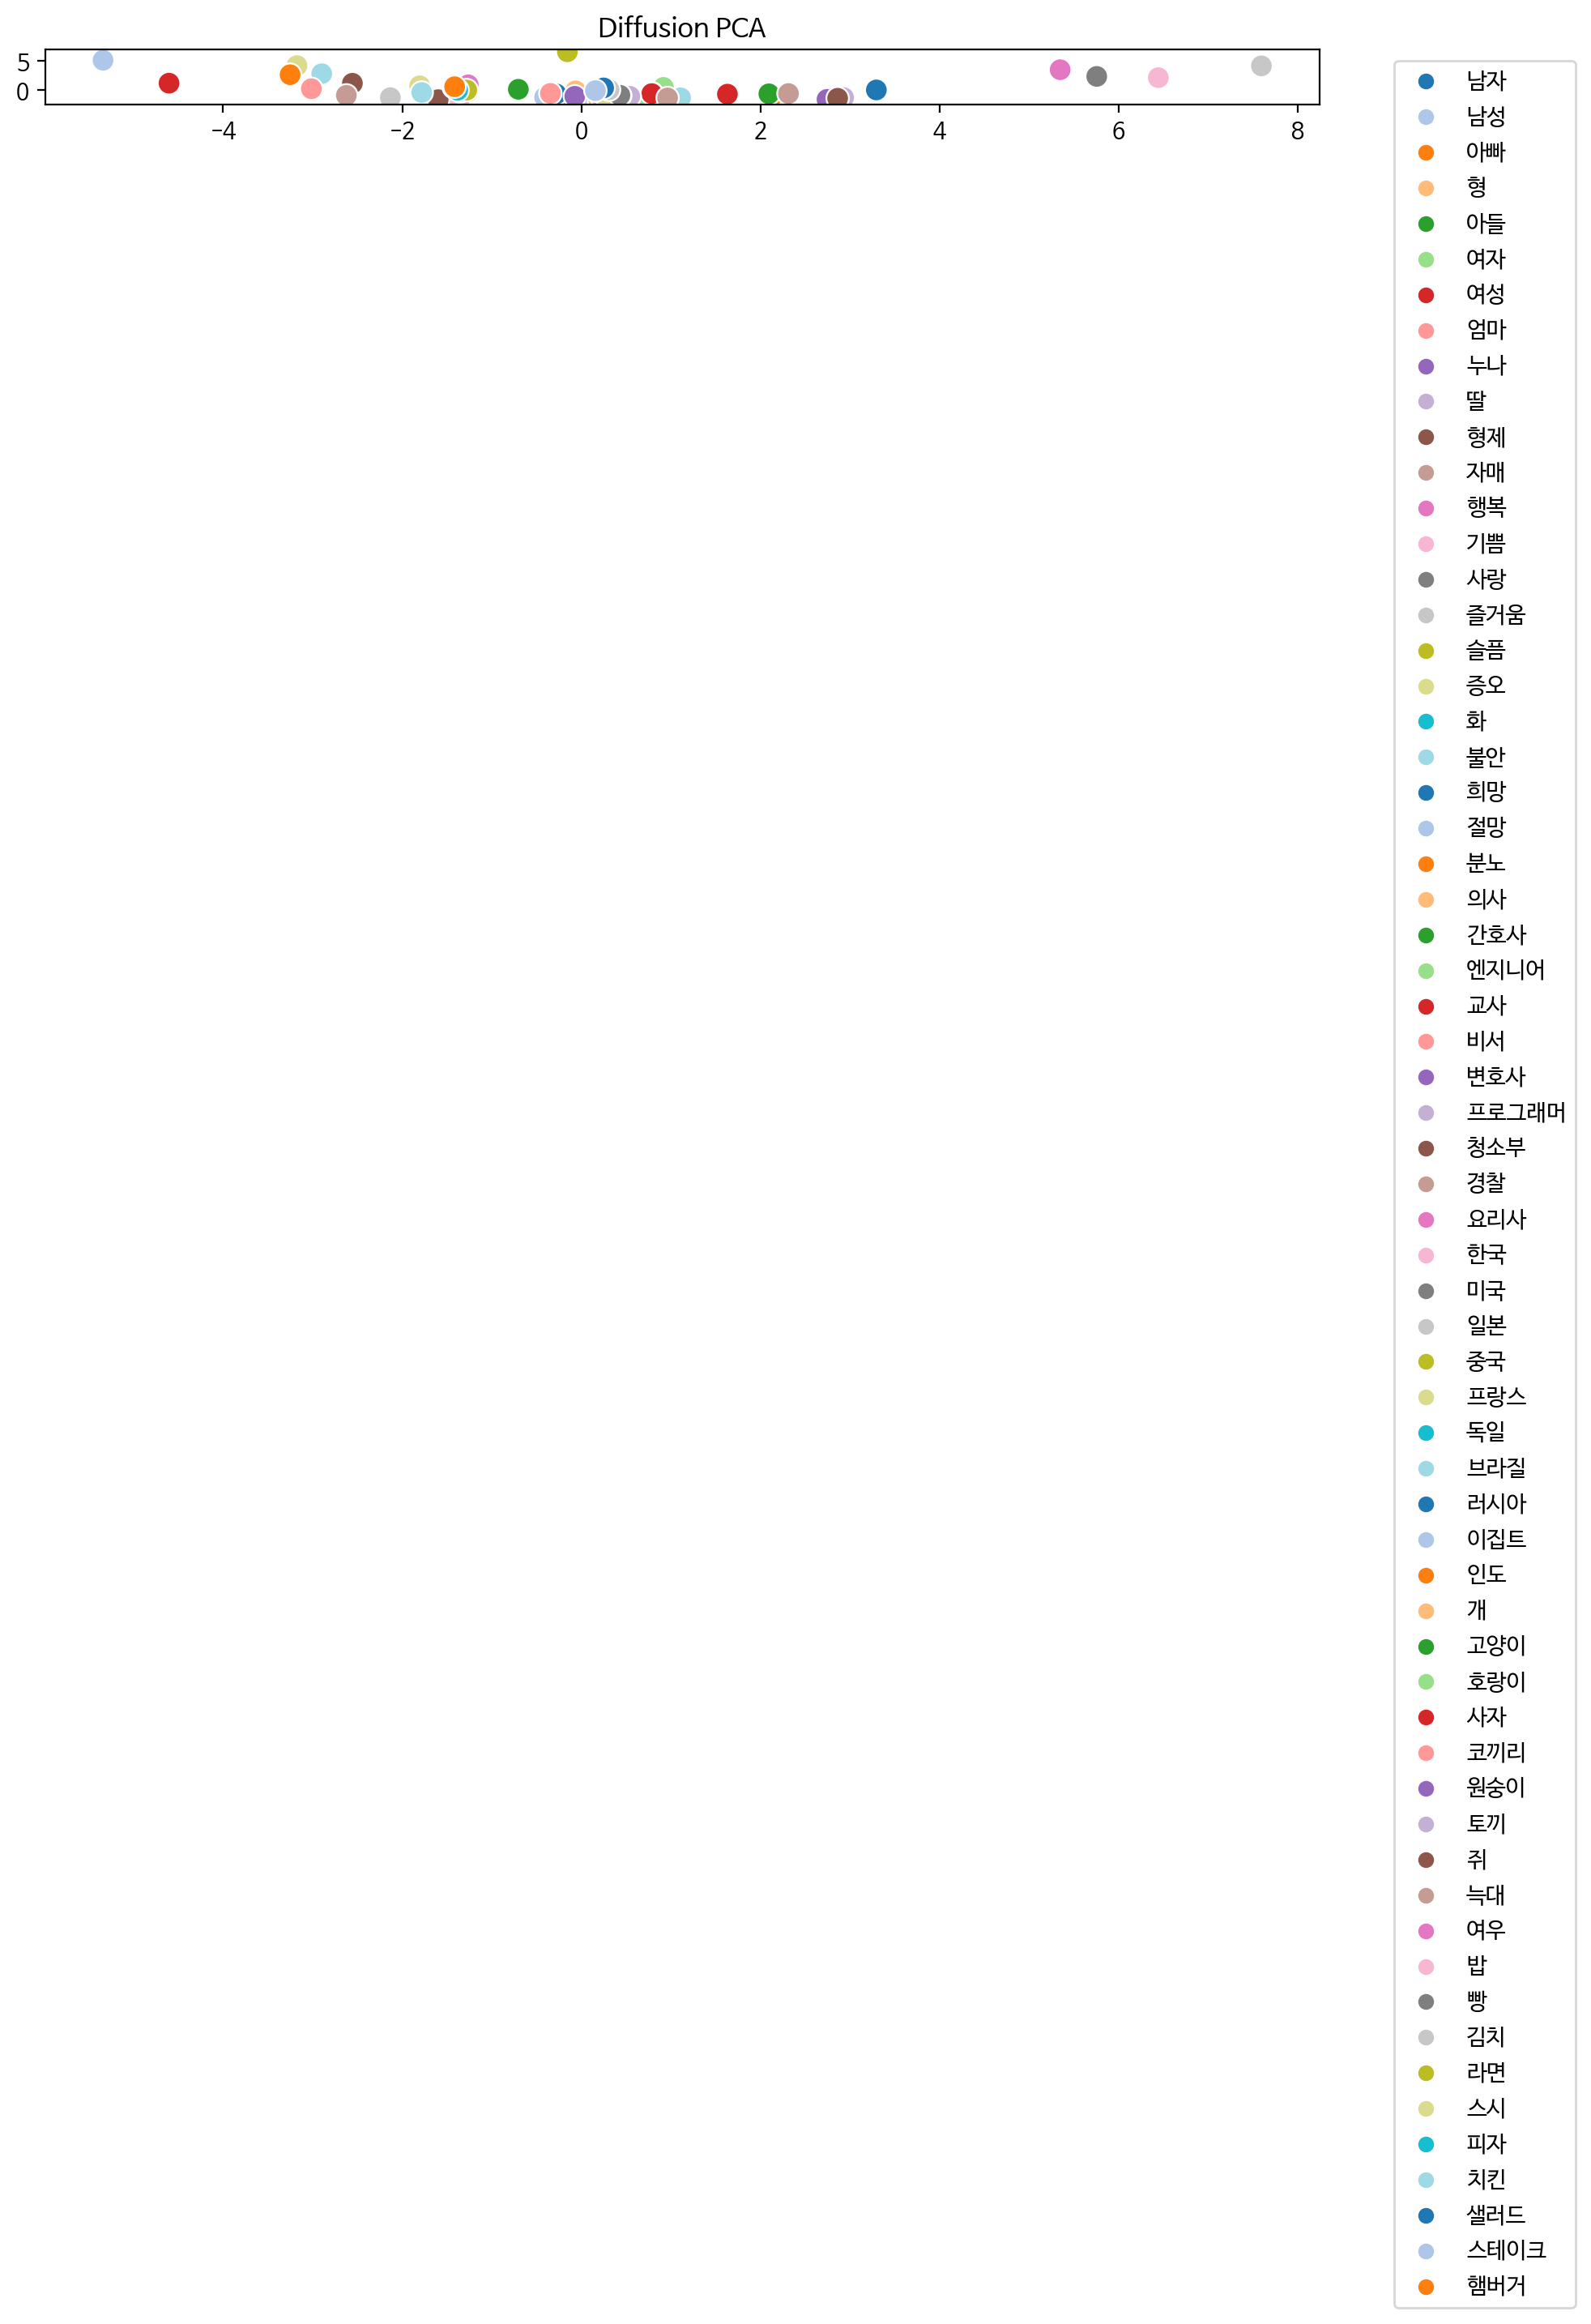

시각화 완료! 모든 이미지 PNG로 저장됨.


In [42]:
# 1. 공통 시각화 함수
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# 2. Cosine Similarity 히트맵
def plot_similarity(embeds, title, filename):
    sim = cosine_similarity(embeds)
    plt.figure(figsize=(12,10))
    sns.heatmap(sim, xticklabels=all_words, yticklabels=all_words, cmap='coolwarm')
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_similarity(baseline_embeds, "Baseline Cosine Similarity", "baseline_similarity.png")
plot_similarity(gaussian_embeds, "Gaussian Cosine Similarity", "gaussian_similarity.png")
plot_similarity(diffusion_embeds, "Diffusion Cosine Similarity", "diffusion_similarity.png")

# 3. t-SNE 시각화
def plot_tsne(embeds, title, filename):
    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(embeds)
    plt.figure(figsize=(10,8))
    sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=all_words, palette="tab20", s=100)
    plt.title(title)
    plt.legend(loc='best', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_tsne(baseline_embeds, "Baseline t-SNE", "baseline_tsne.png")
plot_tsne(gaussian_embeds, "Gaussian t-SNE", "gaussian_tsne.png")
plot_tsne(diffusion_embeds, "Diffusion t-SNE", "diffusion_tsne.png")

# 4. PCA 시각화
def plot_pca(embeds, title, filename):
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embeds)
    plt.figure(figsize=(10,8))
    sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=all_words, palette="tab20", s=100)
    plt.title(title)
    plt.legend(loc='best', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_pca(baseline_embeds, "Baseline PCA", "baseline_pca.png")
plot_pca(gaussian_embeds, "Gaussian PCA", "gaussian_pca.png")
plot_pca(diffusion_embeds, "Diffusion PCA", "diffusion_pca.png")

print("시각화 완료! 모든 이미지 PNG로 저장됨.")


In [43]:
import pandas as pd
from itertools import combinations

# 1. Cosine Similarity → Top/Bottom 출력 + CSV 저장
def analyze_cosine(embeds, mode):
    sim_matrix = cosine_similarity(embeds)
    pairs = []
    for i, j in combinations(range(len(all_words)), 2):
        pairs.append((all_words[i], all_words[j], sim_matrix[i][j]))

    # DataFrame
    sim_df = pd.DataFrame(pairs, columns=['Word1', 'Word2', 'CosineSimilarity'])
    sim_df_sorted = sim_df.sort_values(by='CosineSimilarity', ascending=False)

    print(f"\n==== {mode.upper()} Cosine Similarity Top 10 ====")
    print(sim_df_sorted.head(10).to_string(index=False))

    print(f"\n==== {mode.upper()} Cosine Similarity Bottom 10 ====")
    print(sim_df_sorted.tail(10).to_string(index=False))

    # CSV 저장
    sim_df.to_csv(f'cosine_similarity_{mode}.csv', index=False)
    print(f"Cosine Similarity CSV 저장됨: cosine_similarity_{mode}.csv")

# Baseline
analyze_cosine(baseline_embeds, 'baseline')
# Gaussian
analyze_cosine(gaussian_embeds, 'gaussian')
# Diffusion
analyze_cosine(diffusion_embeds, 'diffusion')

# 2. t-SNE → 좌표 출력 + CSV 저장
def analyze_tsne(embeds, mode):
    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(embeds)
    tsne_df = pd.DataFrame(tsne_result, columns=['x', 'y'])
    tsne_df['Word'] = all_words
    print(f"\n==== {mode.upper()} t-SNE Coordinates ====")
    print(tsne_df[['Word', 'x', 'y']].to_string(index=False))

    tsne_df.to_csv(f'tsne_{mode}.csv', index=False)
    print(f"t-SNE CSV 저장됨: tsne_{mode}.csv")

# Baseline
analyze_tsne(baseline_embeds, 'baseline')
# Gaussian
analyze_tsne(gaussian_embeds, 'gaussian')
# Diffusion
analyze_tsne(diffusion_embeds, 'diffusion')

# 3. PCA → 좌표 출력 + CSV 저장
def analyze_pca(embeds, mode):
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embeds)
    pca_df = pd.DataFrame(pca_result, columns=['x', 'y'])
    pca_df['Word'] = all_words
    print(f"\n==== {mode.upper()} PCA Coordinates ====")
    print(pca_df[['Word', 'x', 'y']].to_string(index=False))

    pca_df.to_csv(f'pca_{mode}.csv', index=False)
    print(f"PCA CSV 저장됨: pca_{mode}.csv")

# Baseline
analyze_pca(baseline_embeds, 'baseline')
# Gaussian
analyze_pca(gaussian_embeds, 'gaussian')
# Diffusion
analyze_pca(diffusion_embeds, 'diffusion')

print("\n=== 모든 Cosine, t-SNE, PCA 수치 출력 & CSV 저장 완료 ===")



==== BASELINE Cosine Similarity Top 10 ====
Word1 Word2  CosineSimilarity
   기쁨   즐거움          0.936779
   아들     딸          0.932669
   행복    기쁨          0.927268
   아빠    누나          0.921161
   피자   햄버거          0.909406
   형제    자매          0.909076
   늑대    여우          0.907935
   치킨   햄버거          0.906001
   행복   즐거움          0.904066
  호랑이    늑대          0.897913

==== BASELINE Cosine Similarity Bottom 10 ====
Word1 Word2  CosineSimilarity
   남자    절망          0.224734
   행복    경찰          0.210527
   슬픔    한국          0.209616
   분노    미국          0.209415
   희망    라면          0.207712
   분노    한국          0.198689
  즐거움    라면          0.197863
   기쁨    라면          0.193854
   사랑    라면          0.192967
   슬픔    미국          0.169311
Cosine Similarity CSV 저장됨: cosine_similarity_baseline.csv

==== GAUSSIAN Cosine Similarity Top 10 ====
Word1 Word2  CosineSimilarity
   행복    기쁨          0.917279
   아빠    누나          0.890454
   기쁨   즐거움          0.889910
   남성    여성          0.8


==== BASELINE - gender_emotion WEAT ====
A-X 평균 Cosine: 0.5280
A-Y 평균 Cosine: 0.4359
B-X 평균 Cosine: 0.5136
B-Y 평균 Cosine: 0.4341
Effect Size (Cohen's d): 0.1250

==== GAUSSIAN - gender_emotion WEAT ====
A-X 평균 Cosine: 0.5486
A-Y 평균 Cosine: 0.4667
B-X 평균 Cosine: 0.5260
B-Y 평균 Cosine: 0.4733
Effect Size (Cohen's d): 0.2317

==== DIFFUSION - gender_emotion WEAT ====
A-X 평균 Cosine: 0.5632
A-Y 평균 Cosine: 0.4778
B-X 평균 Cosine: 0.5930
B-Y 평균 Cosine: 0.4545
Effect Size (Cohen's d): -0.5830

==== BASELINE - job_bias WEAT ====
A-X 평균 Cosine: 0.6529
A-Y 평균 Cosine: 0.6415
B-X 평균 Cosine: 0.5930
B-Y 평균 Cosine: 0.5974
Effect Size (Cohen's d): 0.6926

==== GAUSSIAN - job_bias WEAT ====
A-X 평균 Cosine: 0.6521
A-Y 평균 Cosine: 0.6111
B-X 평균 Cosine: 0.5631
B-Y 평균 Cosine: 0.5578
Effect Size (Cohen's d): 1.1806

==== DIFFUSION - job_bias WEAT ====
A-X 평균 Cosine: 0.6240
A-Y 평균 Cosine: 0.5913
B-X 평균 Cosine: 0.5724
B-Y 평균 Cosine: 0.5362
Effect Size (Cohen's d): -0.2260

==== BASELINE - country_group WEAT ====
A

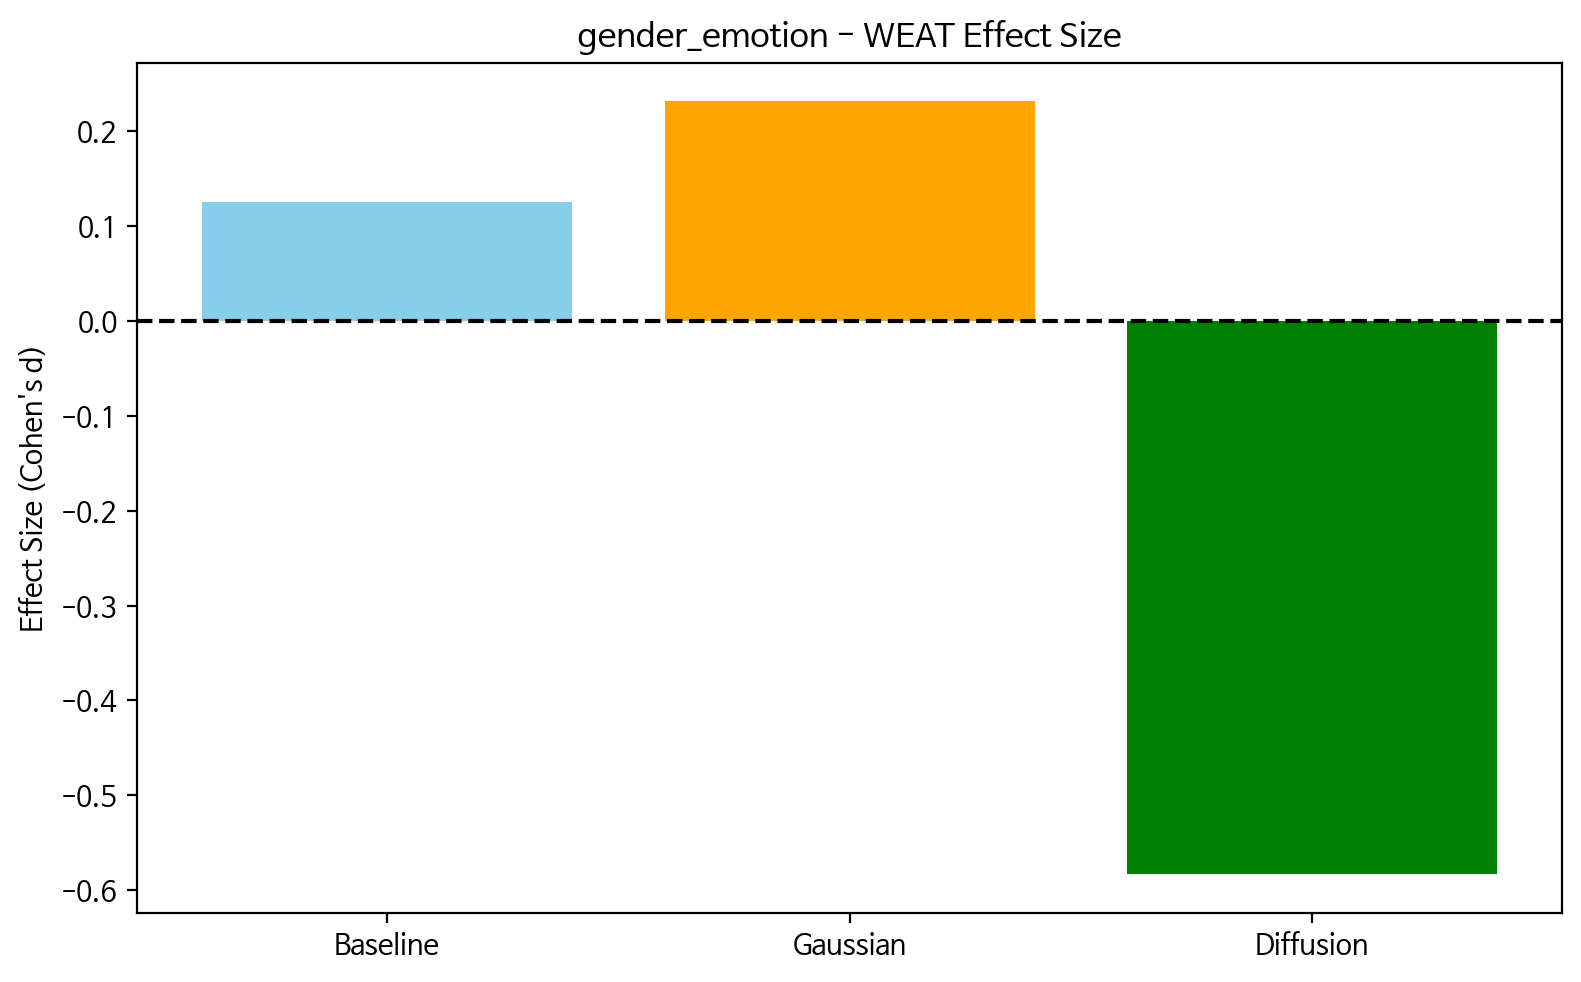

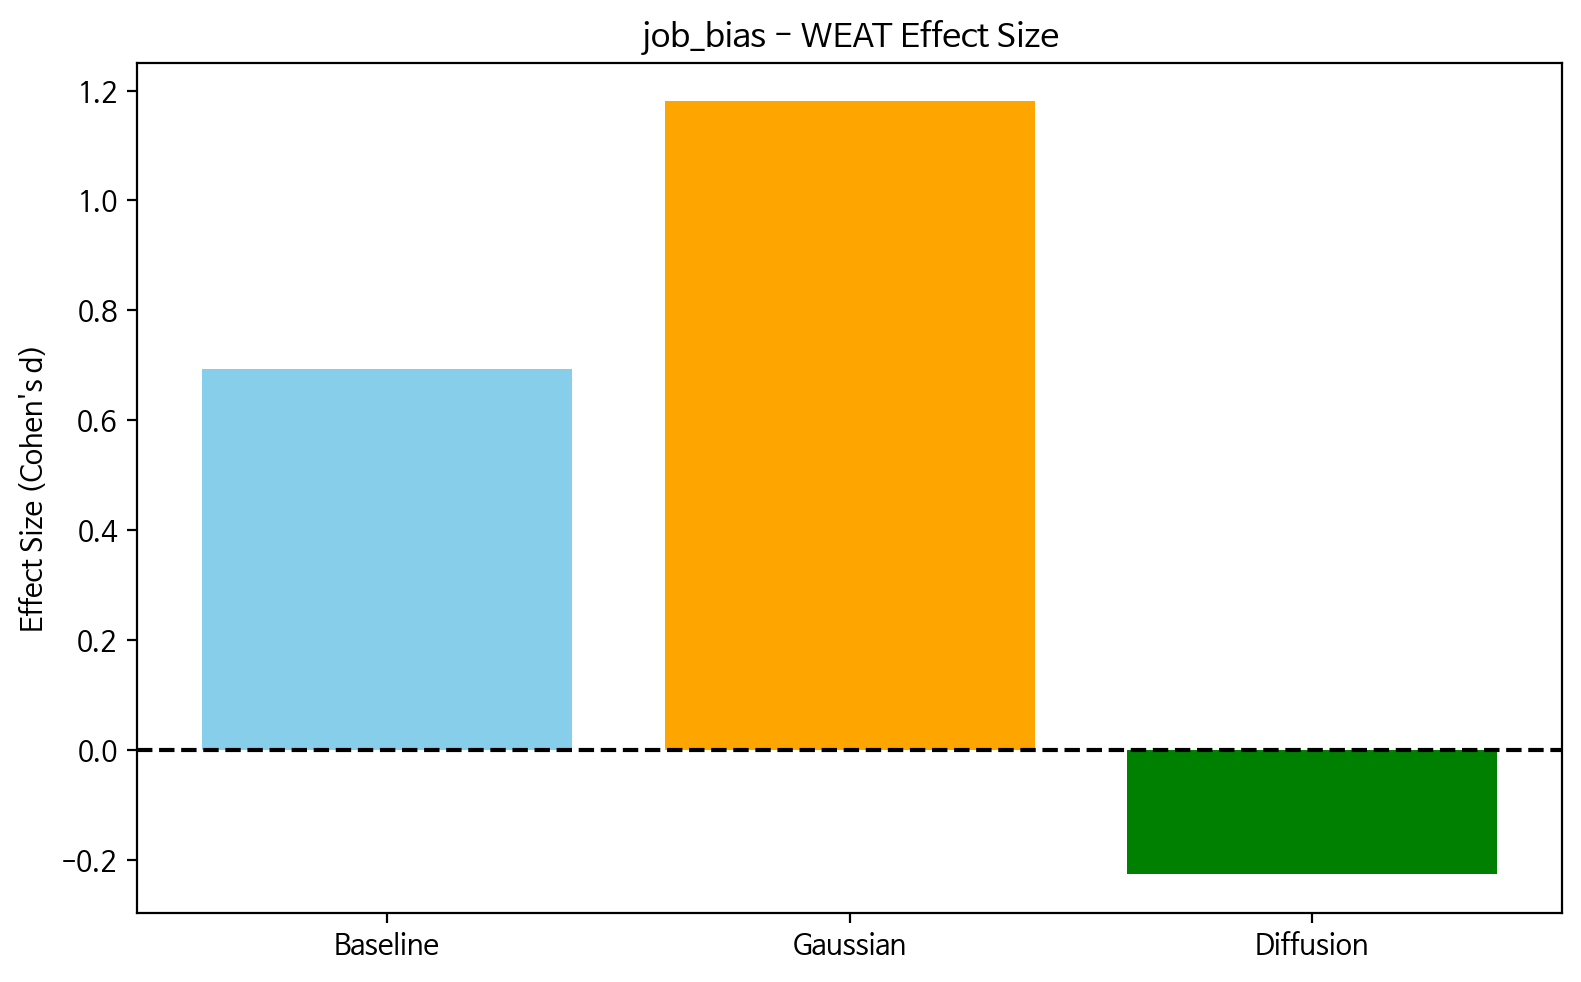

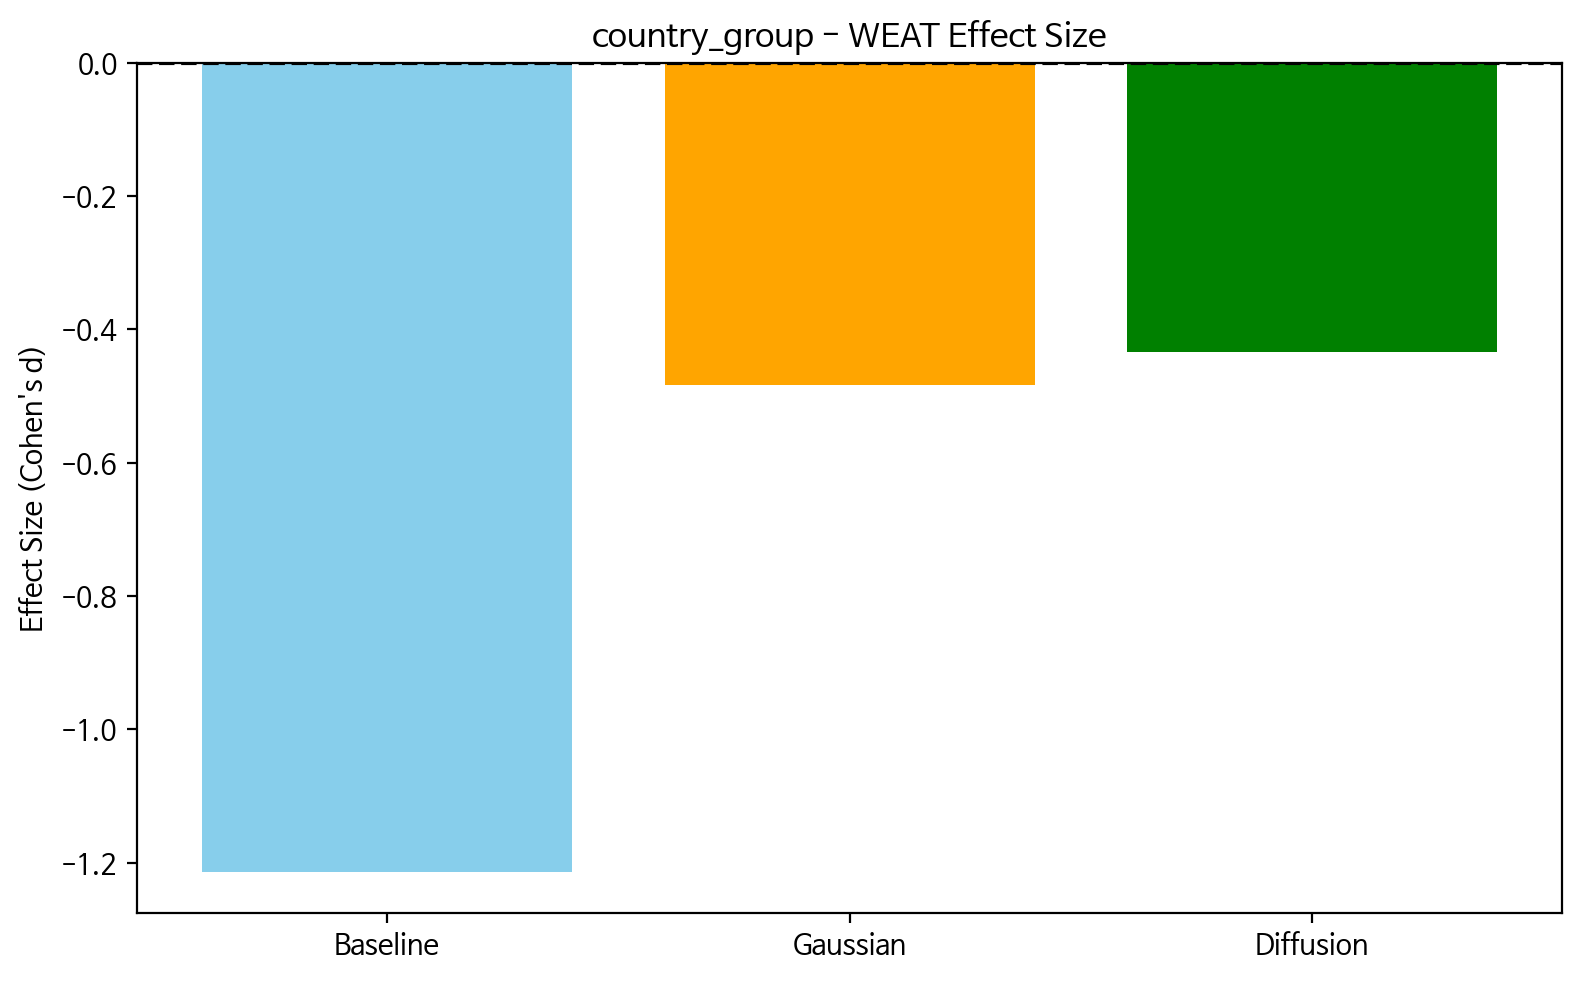


=== 모든 WEAT 실험, 시각화, CSV 저장 완료 ===


In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np


# 1. WEAT 실험 세트 정의
weat_tests = {
    "gender_emotion": {
        "Target_A": ["남자", "남성", "아빠", "형", "아들"],
        "Target_B": ["여자", "여성", "엄마", "누나", "딸"],
        "Attribute_1": ["행복", "기쁨", "사랑", "즐거움", "희망"],
        "Attribute_2": ["슬픔", "증오", "화", "불안", "절망"]
    },
    "job_bias": {
        "Target_A": ["의사", "엔지니어", "프로그래머", "경찰", "변호사"],
        "Target_B": ["간호사", "비서", "청소부", "교사", "요리사"],
        "Attribute_1": ["남자", "남성", "아빠", "형", "아들"],
        "Attribute_2": ["여자", "여성", "엄마", "누나", "딸"]
    },
    "country_group": {
        "Target_A": ["한국", "일본", "중국", "러시아", "브라질"],
        "Target_B": ["미국", "프랑스", "독일", "이집트", "인도"],
        "Attribute_1": ["행복", "기쁨", "희망"],
        "Attribute_2": ["슬픔", "화", "절망"]
    }
}

# 2. WEAT 계산 함수 (확장형)
def compute_weat_extended(embeds, mode, test_name, target_A, target_B, attribute_1, attribute_2):
    word_to_vec = {word: vec for word, vec in zip(all_words, embeds)}

    A_vecs = np.array([word_to_vec[w] for w in target_A])
    B_vecs = np.array([word_to_vec[w] for w in target_B])
    X_vecs = np.array([word_to_vec[w] for w in attribute_1])
    Y_vecs = np.array([word_to_vec[w] for w in attribute_2])

    def avg_cosine(vecs1, vecs2):
        sims = cosine_similarity(vecs1, vecs2)
        return np.mean(sims)

    A_X = avg_cosine(A_vecs, X_vecs)
    A_Y = avg_cosine(A_vecs, Y_vecs)
    B_X = avg_cosine(B_vecs, X_vecs)
    B_Y = avg_cosine(B_vecs, Y_vecs)

    s_X = np.mean([cosine_similarity([a], X_vecs).mean() for a in A_vecs]) - \
          np.mean([cosine_similarity([b], X_vecs).mean() for b in B_vecs])
    s_Y = np.mean([cosine_similarity([a], Y_vecs).mean() for a in A_vecs]) - \
          np.mean([cosine_similarity([b], Y_vecs).mean() for b in B_vecs])
    
    std_dev = np.std(np.concatenate([
        [cosine_similarity([a], X_vecs).mean() - cosine_similarity([a], Y_vecs).mean() for a in A_vecs],
        [cosine_similarity([b], X_vecs).mean() - cosine_similarity([b], Y_vecs).mean() for b in B_vecs]
    ]))
    
    effect_size = (s_X - s_Y) / std_dev if std_dev != 0 else 0

    # 콘솔 출력
    print(f"\n==== {mode.upper()} - {test_name} WEAT ====")
    print(f"A-X 평균 Cosine: {A_X:.4f}")
    print(f"A-Y 평균 Cosine: {A_Y:.4f}")
    print(f"B-X 평균 Cosine: {B_X:.4f}")
    print(f"B-Y 평균 Cosine: {B_Y:.4f}")
    print(f"Effect Size (Cohen's d): {effect_size:.4f}")

    # CSV 저장
    df = pd.DataFrame({
        'Metric': ['A_X_mean', 'A_Y_mean', 'B_X_mean', 'B_Y_mean', 'Effect_Size'],
        'Value': [A_X, A_Y, B_X, B_Y, effect_size]
    })
    df.to_csv(f'weat_{test_name}_{mode}.csv', index=False)

    return effect_size

# 3. 모델별, 테스트별로 수행
results = { "baseline": {}, "gaussian": {}, "diffusion": {} }

for test_name, groups in weat_tests.items():
    results['baseline'][test_name] = compute_weat_extended(
        baseline_embeds, 'baseline', test_name,
        groups['Target_A'], groups['Target_B'], groups['Attribute_1'], groups['Attribute_2']
    )
    results['gaussian'][test_name] = compute_weat_extended(
        gaussian_embeds, 'gaussian', test_name,
        groups['Target_A'], groups['Target_B'], groups['Attribute_1'], groups['Attribute_2']
    )
    results['diffusion'][test_name] = compute_weat_extended(
        diffusion_embeds, 'diffusion', test_name,
        groups['Target_A'], groups['Target_B'], groups['Attribute_1'], groups['Attribute_2']
    )

# 4. Effect Size 시각화
for test_name in weat_tests.keys():
    plt.figure(figsize=(8,5))
    plt.bar(['Baseline', 'Gaussian', 'Diffusion'], 
            [results['baseline'][test_name], results['gaussian'][test_name], results['diffusion'][test_name]],
            color=['skyblue', 'orange', 'green'])
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"{test_name} - WEAT Effect Size")
    plt.ylabel("Effect Size (Cohen's d)")
    plt.tight_layout()
    plt.savefig(f'weat_effect_size_{test_name}.png')
    plt.show()

print("\n=== 모든 WEAT 실험, 시각화, CSV 저장 완료 ===")
